<a href="https://colab.research.google.com/github/FarhanKO/Disease-Risk-Prediction/blob/main/Research/Heart/Heart_Diseases_Tabular.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Heart Disease Prediction & Clinical Risk Stratification

## Project Overview
This project aims to build a robust, clinically actionable machine learning pipeline for predicting heart disease. Using a comprehensive dataset of patient clinical records, the objective is not only to classify patients as healthy or at-risk with high accuracy but also to ensure the model's decisions are explainable, reliable, and practically deployable in a medical setting.

## Key Methodologies
Our approach is divided into several advanced stages to ensure maximum clinical safety and model transparency:

1. **Data Preprocessing & Feature Engineering:** Handling missing values, scaling clinical metrics, managing class imbalances using SMOTE, and creating custom interaction features (e.g., maximum heart rate ratios and blood pressure indices).
2. **Supervised Classification:** Training and comparing multiple machine learning models (Logistic Regression, Random Forest, XGBoost, CatBoost, Neural Networks, etc.) to find the most accurate predictor, prioritizing **Recall (Sensitivity)** to minimize dangerous False Negatives.
3. **Clinical Calibration & Threshold Optimization:** Adjusting the prediction thresholds based on clinical cost functions (penalizing missed diagnoses heavier than false alarms) and calibrating the probabilities so they reflect real-world risks.
4. **Explainable AI (XAI):** Utilizing SHAP (SHapley Additive exPlanations) to crack open the "black box" of the model, providing doctors with patient-specific, transparent reasoning for every prediction.
5. **Unsupervised Learning & Anomaly Detection:** Using clustering (K-Means, GMM) to find natural patient profiles and an ensemble of anomaly detectors (Isolation Forest, SVM, Autoencoders) to act as a "gatekeeper," catching extreme clinical anomalies or data entry errors before they reach the main diagnostic model.

This end-to-end pipeline represents a complete "Cascade Architecture" designed for real-world medical deployment.

# Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline # Kept for standard preprocessing
from imblearn.pipeline import Pipeline as ImbPipeline # Required for SMOTE integration
from imblearn.over_sampling import SMOTE # Synthetic minority over-sampling
from xgboost import XGBClassifier # Advanced Gradient Boosting

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.model_selection import StratifiedKFold

from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_score, recall_score, precision_recall_curve, roc_curve, auc
)

from sklearn.preprocessing import FunctionTransformer

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans
from sklearn.neural_network import MLPClassifier

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture

# Load Database & Discription

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/AI Projects/Heart Diseases/Heart Diseases.csv")
display(df.head())
df.info()
df.columns
df.describe()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


Target Distribution (Imbalanced Dataset Check)

In [ ]:
print(df['num'].value_counts(dropna=False))
df = df.dropna(subset=['num'])   # Remove Row that has no num

num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64


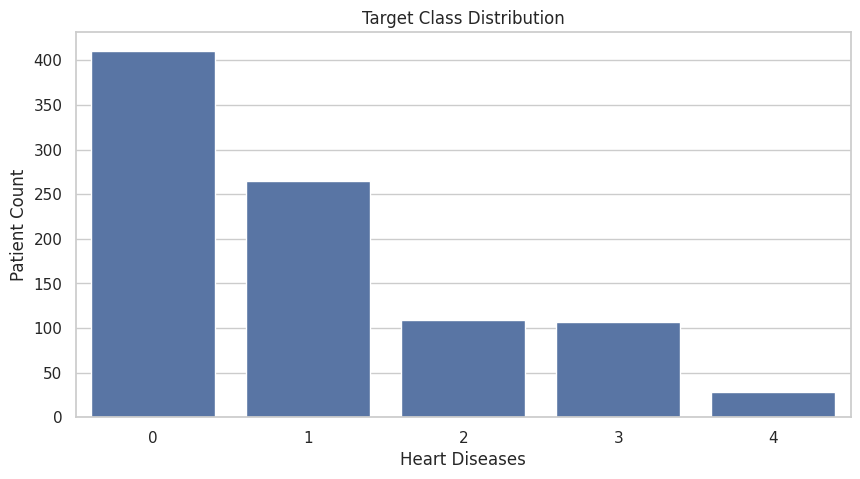

In [ ]:
plt.figure(figsize = (10,5))
sns.countplot(x="num", data=df)
plt.xlabel("Heart Diseases")
plt.ylabel("Patient Count")
plt.title("Target Class Distribution")
plt.show()

Correlation Analysis (Heatmap)

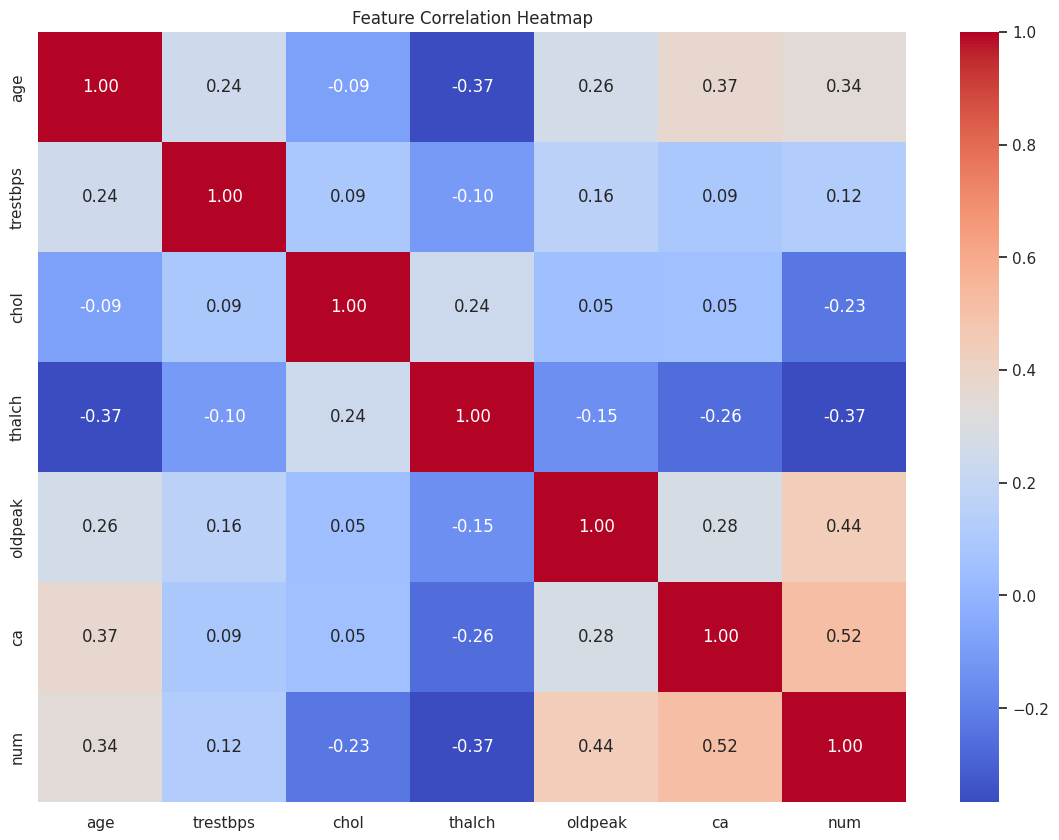

In [ ]:
# Drop the 'id' column and save the change back to df
df = df.drop(columns=['id'], errors='ignore')

plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

Some Feature Engineering we use

In [ ]:
expected_max_hr = 220 - df['age']         # 1e-5 (0.00001) to avoid ZeroDivisionError
df['max_hr_ratio'] = df['thalch'] / (expected_max_hr + 1e-5)
df['bp_hr_index'] = df['trestbps'] / (df['thalch'] + 1e-5)
df['age_st_interaction'] = df['age'] * df['oldpeak']

df.head()

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num,max_hr_ratio,bp_hr_index,age_st_interaction
0,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0,0.955414,0.966667,144.9
1,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2,0.705882,1.481481,100.5
2,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1,0.843137,0.930232,174.2
3,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0,1.021858,0.695187,129.5
4,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0,0.960894,0.755814,57.4


In [ ]:
def add_custom_features(X):
    # Create a copy to avoid mutating the original dataframe slice
    X_out = X.copy()

    # Max Heart Rate Ratio
    expected_max_hr = 220 - X_out['age']
    X_out['max_hr_ratio'] = X_out['thalch'] / (expected_max_hr + 1e-5)

    # Blood Pressure Heart Rate Index
    X_out['bp_hr_index'] = X_out['trestbps'] / (X_out['thalch'] + 1e-5)

    # Age & ST Depression Interaction
    X_out['age_st_interaction'] = X_out['age'] * X_out['oldpeak']

    return X_out

# Dataset Pre-processing

In [ ]:
X = df.drop(['max_hr_ratio', 'bp_hr_index', 'age_st_interaction', 'num'], axis=1)
y = (df['num'] > 0).astype(int)          # Multi-VAlue = 0,1

feature_engineering = FunctionTransformer(add_custom_features)

categorical_features = X.select_dtypes(include=["object"]).columns
numerical_existing_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
numerical_features = numerical_existing_features + ['max_hr_ratio', 'bp_hr_index', 'age_st_interaction']

numeric_sub_pipeline = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),     # Look at 5 similer nei and avg their value
    ('scaler', RobustScaler())                  # Upgraded to RobustScaler to handle clinical outliers
])

categorical_sub_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Consolidate transformers into a universal block variable
preprocessor = ColumnTransformer(
    transformers=[
        ('num_transform', numeric_sub_pipeline, numerical_features),
        ('cat_transform', categorical_sub_pipeline, categorical_features)
])

global_preprocessor = Pipeline(steps=[
    ('engineering', feature_engineering), # Step 1: Calculate Wickets_per_Over automatically
    ('transformations', preprocessor)  # Step 2: Scale numbers and encode text strings
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Model Training

### Logistic Regression

In [ ]:
lr_pipeline = ImbPipeline(steps=[
    ('engineering', feature_engineering),
    ('transformations', preprocessor),
    ('smote', SMOTE(random_state=42)), # Synthetically balances positive/negative cases
    ('classifier', LogisticRegression(max_iter=2000, random_state=42))
])

lr_param_grid = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100], # Regularization strength (smaller = stronger penalty to prevent overfitting)
    'classifier__penalty': ['l1', 'l2'], # L1 drops useless features (Lasso), L2 shrinks them evenly (Ridge)
    'classifier__solver': ['liblinear', 'saga'] # Optimization algorithms that support both L1 and L2
}

lr_grid = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_param_grid,
    cv=cv_strategy,
    scoring='recall',
    n_jobs=-1
)

lr_grid.fit(X_train, y_train)
lr_pred = lr_grid.predict(X_test)

print(f"Logistic Regression Best Score: {lr_grid.best_score_:.4f}")
print(f"\n--- Logistic Regression Metrics ---")
print(classification_report(y_test, lr_pred, target_names=['Healthy', 'Disease']))

Logistic Regression Best Score: 0.8303

--- Logistic Regression Metrics ---
              precision    recall  f1-score   support

     Healthy       0.81      0.79      0.80        82
     Disease       0.84      0.85      0.84       102

    accuracy                           0.83       184
   macro avg       0.82      0.82      0.82       184
weighted avg       0.83      0.83      0.83       184



### KNN Classifier

In [ ]:
knn_pipeline = ImbPipeline(steps=[
    ('engineering', feature_engineering),
    ('transformations', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', KNeighborsClassifier())
])

knn_param_grid = {
    'classifier__n_neighbors': [3, 5, 7, 9, 11], # How many nearby patients to look at for prediction
    'classifier__weights': ['uniform', 'distance'], # Uniform = all neighbors equal, Distance = closer neighbors count more
    'classifier__p': [1, 2] # 1: Manhattan Distance (grid-like), 2: Euclidean Distance (straight line)
}

knn_grid = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=knn_param_grid,
    cv=cv_strategy,
    scoring='recall',
    n_jobs=-1
)

knn_grid.fit(X_train, y_train)
knn_pred = knn_grid.predict(X_test)

print(f"KNN Best Score: {knn_grid.best_score_:.4f}")
print(f"\n--- KNN Metrics ---")
print(classification_report(y_test, knn_pred, target_names=['Healthy', 'Disease']))

KNN Best Score: 0.8353

--- KNN Metrics ---
              precision    recall  f1-score   support

     Healthy       0.85      0.82      0.83        82
     Disease       0.86      0.88      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184



### Decision Tree

In [ ]:
dt_pipeline = ImbPipeline(steps=[
    ('engineering', feature_engineering),
    ('transformations', preprocessor),
    ('smote', SMOTE(random_state=42)), # Replaces class_weight='balanced' naturally
    ('classifier', DecisionTreeClassifier(random_state=42))
])

dt_param_grid = {
    'classifier__criterion': ['gini', 'entropy'], # Math used to decide where to split the data
    'classifier__max_depth': [3, 5, 7, 10, 15, None], # Max number of levels in the tree (stops it from memorizing data)
    'classifier__min_samples_split': [2, 5, 10, 20], # Minimum patients required to split a node further
    'classifier__min_samples_leaf': [1, 2, 4, 8], # Minimum patients that must be in an end leaf
    'classifier__max_features': [None, 'sqrt', 'log2'] # Number of features considered at each split to add randomness
}

dt_grid = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=dt_param_grid,
    cv=cv_strategy,
    scoring='recall',
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)
dt_pred = dt_grid.predict(X_test)

print(f"Decision Tree Best Score: {dt_grid.best_score_:.4f}")
print(f"\n--- Decision Tree Metrics ---")
print(classification_report(y_test, dt_pred, target_names=['Healthy', 'Disease']))

Decision Tree Best Score: 0.8501

--- Decision Tree Metrics ---
              precision    recall  f1-score   support

     Healthy       0.68      0.87      0.76        82
     Disease       0.86      0.67      0.75       102

    accuracy                           0.76       184
   macro avg       0.77      0.77      0.76       184
weighted avg       0.78      0.76      0.75       184



### Random Forest Classifier

In [ ]:
rf_pipeline = ImbPipeline(steps=[
    ('engineering', feature_engineering),
    ('transformations', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42))
])

rf_param_grid = {
    'classifier__n_estimators': [100, 200, 300], # Number of trees in the forest
    'classifier__max_depth': [6, 8, 12, None], # Max depth for each individual tree
    'classifier__min_samples_split': [2, 5, 10], # Min patients needed to split
    'classifier__min_samples_leaf': [1, 2, 4], # Min patients needed in a leaf
    'classifier__max_features': ['sqrt', 'log2'], # Random subset of features for each tree
    'classifier__bootstrap': [True, False] # True means each tree gets a random sample of the training data
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=cv_strategy,
    scoring='recall',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)
rf_pred = rf_grid.predict(X_test)

print(f"Random Forest Best Score: {rf_grid.best_score_:.4f}")
print(f"\n--- Random Forest Metrics ---")
print(classification_report(y_test, rf_pred, target_names=['Healthy', 'Disease']))

Random Forest Best Score: 0.8476

--- Random Forest Metrics ---
              precision    recall  f1-score   support

     Healthy       0.84      0.82      0.83        82
     Disease       0.86      0.87      0.86       102

    accuracy                           0.85       184
   macro avg       0.85      0.84      0.85       184
weighted avg       0.85      0.85      0.85       184



### Naive Bayes

In [ ]:
nb_pipeline = ImbPipeline(steps=[
    ('engineering', feature_engineering),
    ('transformations', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', GaussianNB())
])

nb_param_grid = {
    'classifier__var_smoothing': np.logspace(0, -9, num=20) # Adds a tiny variance to prevent dividing by zero probabilities
}

nb_grid = GridSearchCV(
    estimator=nb_pipeline,
    param_grid=nb_param_grid,
    cv=cv_strategy,
    scoring='recall',
    n_jobs=-1
)

nb_grid.fit(X_train, y_train)
nb_pred = nb_grid.predict(X_test)

print(f"Naive Bayes Best Score: {nb_grid.best_score_:.4f}")
print(f"\n--- Naive Bayes Metrics ---")
print(classification_report(y_test, nb_pred, target_names=['Healthy', 'Disease']))

Naive Bayes Best Score: 0.8303

--- Naive Bayes Metrics ---
              precision    recall  f1-score   support

     Healthy       0.84      0.82      0.83        82
     Disease       0.86      0.87      0.86       102

    accuracy                           0.85       184
   macro avg       0.85      0.84      0.85       184
weighted avg       0.85      0.85      0.85       184



### Neural Network (MLP)

In [ ]:
nn_pipeline = ImbPipeline(steps=[
    ('engineering', feature_engineering),
    ('transformations', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', MLPClassifier(max_iter=1000, random_state=42))
])

nn_param_grid = {
    'classifier__hidden_layer_sizes': [(32,16), (64,32), (100,)], # Architecture: (neurons in layer 1, neurons in layer 2)
    'classifier__activation': ['relu', 'tanh'], # The math function neurons use to output a signal
    'classifier__alpha': [0.0001, 0.001, 0.01], # L2 Regularization to stop the network from overfitting
    'classifier__learning_rate': ['constant', 'adaptive'] # How quickly the network updates its weights during training
}

nn_grid = GridSearchCV(
    estimator=nn_pipeline,
    param_grid=nn_param_grid,
    cv=cv_strategy,
    scoring='recall',
    n_jobs=-1
)

nn_grid.fit(X_train, y_train)
nn_pred = nn_grid.predict(X_test)

print(f"Neural Network Best Score: {nn_grid.best_score_:.4f}")
print(f"\n--- Neural Network Metrics ---")
print(classification_report(y_test, nn_pred, target_names=['Healthy', 'Disease']))

Neural Network Best Score: 0.8452

--- Neural Network Metrics ---
              precision    recall  f1-score   support

     Healthy       0.82      0.77      0.79        82
     Disease       0.82      0.86      0.84       102

    accuracy                           0.82       184
   macro avg       0.82      0.82      0.82       184
weighted avg       0.82      0.82      0.82       184



### XGBoost

In [ ]:
xgb_pipeline = ImbPipeline(steps=[
    ('engineering', feature_engineering),
    ('transformations', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', XGBClassifier(random_state=42, eval_metric='logloss'))
])

xgb_param_grid = {
    'classifier__n_estimators': [100, 200], # Number of boosting rounds (trees)
    'classifier__max_depth': [3, 5, 7], # Depth of each tree (keep shallow for boosting)
    'classifier__learning_rate': [0.01, 0.1, 0.2], # How much each tree contributes to the final prediction
    'classifier__subsample': [0.8, 1.0] # Fraction of samples used per tree (adds randomness)
}

xgb_grid = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_param_grid,
    cv=cv_strategy,
    scoring='recall',
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)
xgb_pred = xgb_grid.predict(X_test)

print(f"XGBoost Best Score: {xgb_grid.best_score_:.4f}")
print(f"\n--- XGBoost Metrics ---")
print(classification_report(y_test, xgb_pred, target_names=['Healthy', 'Disease']))

XGBoost Best Score: 0.8476

--- XGBoost Metrics ---
              precision    recall  f1-score   support

     Healthy       0.84      0.82      0.83        82
     Disease       0.86      0.87      0.86       102

    accuracy                           0.85       184
   macro avg       0.85      0.84      0.85       184
weighted avg       0.85      0.85      0.85       184



### CatBoost

In [ ]:
!pip install catboost

In [ ]:
from catboost import CatBoostClassifier

cb_pipeline = ImbPipeline(steps=[
    ('engineering', feature_engineering),
    ('transformations', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', CatBoostClassifier(random_state=42, verbose=False))
])

cb_param_grid = {
    'classifier__iterations': [100, 200], # Number of boosting trees
    'classifier__depth': [4, 6], # Depth of trees
    'classifier__learning_rate': [0.01, 0.1] # Step size shrinkage
}

cb_grid = GridSearchCV(
    estimator=cb_pipeline,
    param_grid=cb_param_grid,
    cv=cv_strategy,
    scoring='recall',
    n_jobs=-1
)

cb_grid.fit(X_train, y_train)
cb_pred = cb_grid.predict(X_test)

print(f"CatBoost Best Score: {cb_grid.best_score_:.4f}")
print(f"\n--- CatBoost Metrics ---")
print(classification_report(y_test, cb_pred, target_names=['Healthy', 'Disease']))

CatBoost Best Score: 0.8402

--- CatBoost Metrics ---
              precision    recall  f1-score   support

     Healthy       0.87      0.79      0.83        82
     Disease       0.84      0.90      0.87       102

    accuracy                           0.85       184
   macro avg       0.86      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184



# Model Comparison

### Comparison Barchart

Gives better sense of how well my model is performing in considering the minority class.

* **Precision:** How many predicted positives are actually correct.

* **Recall (Sensitivity/ True pos rate):** How many of the actual positives model identified correctly. `Both have to be high`

* F1 Score is mean of these 2 which was not needed in my case. In case, if missing a positive (higher recal = fewer False Negative) case is very costly *prioritize Recall* because it catch many positive as possible. If false positive are problematic, *consider precision.* So in our case, we will consider recall.

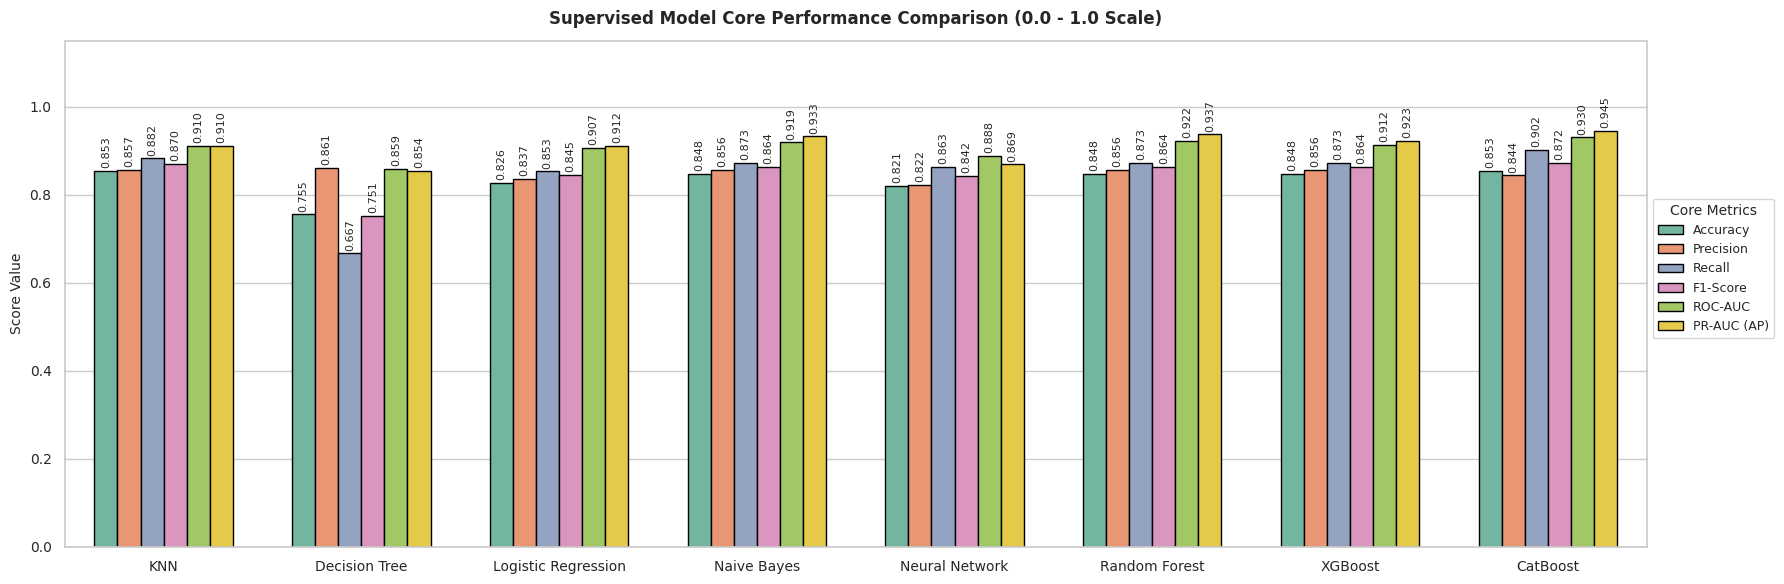

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, \
    precision_score, recall_score, f1_score, average_precision_score, roc_curve, auc

final_models = {
    'KNN': knn_grid.best_estimator_,
    'Decision Tree': dt_grid.best_estimator_,
    'Logistic Regression': lr_grid.best_estimator_,
    'Naive Bayes': nb_grid.best_estimator_,
    'Neural Network': nn_grid.best_estimator_,
    'Random Forest': rf_grid.best_estimator_,
    'XGBoost': xgb_grid.best_estimator_,
    'CatBoost': cb_grid.best_estimator_
}

barchart_data = []
for name, model in final_models.items():
    preds = model.predict(X_test)
    probas = model.predict_proba(X_test)[:, 1]
    barchart_data.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds, zero_division=0),
        'Recall': recall_score(y_test, preds, zero_division=0),
        'F1-Score': f1_score(y_test, preds, zero_division=0),
        'ROC-AUC': auc(*roc_curve(y_test, probas)[:2]),
        'PR-AUC (AP)': average_precision_score(y_test, probas)
    })

df_barchart = pd.DataFrame(barchart_data)
df_melted = df_barchart.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(18, 6), dpi=100)
sns.set_theme(style="whitegrid")

ax = sns.barplot(data=df_melted,
    x='Model', y='Score',
    hue='Metric', palette='Set2', edgecolor='black', width=0.7)

plt.title('Supervised Model Core Performance Comparison (0.0 - 1.0 Scale)', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('', fontsize=10)
plt.ylabel('Score Value', fontsize=10)
plt.ylim(0, 1.15)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title='Core Metrics', loc='lower left', bbox_to_anchor=(1, 0.4), fontsize=9, title_fontsize=10)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=2, fontsize=8, rotation=90)

plt.tight_layout()
plt.show()

Most critical score to consider is Recall (Sensitivity). A False Negative means the model tells a patient they are perfectly healthy when they actually have heart disease. This is extremely dangerous and could be fatal because the patient won't receive the treatment they need.

Precision is secondary. A False Positive (lowering your Precision) means the model flags a healthy person as having heart disease. While this causes anxiety and requires the patient to take more tests (like an ECG or blood test).

### Confusion Matrix

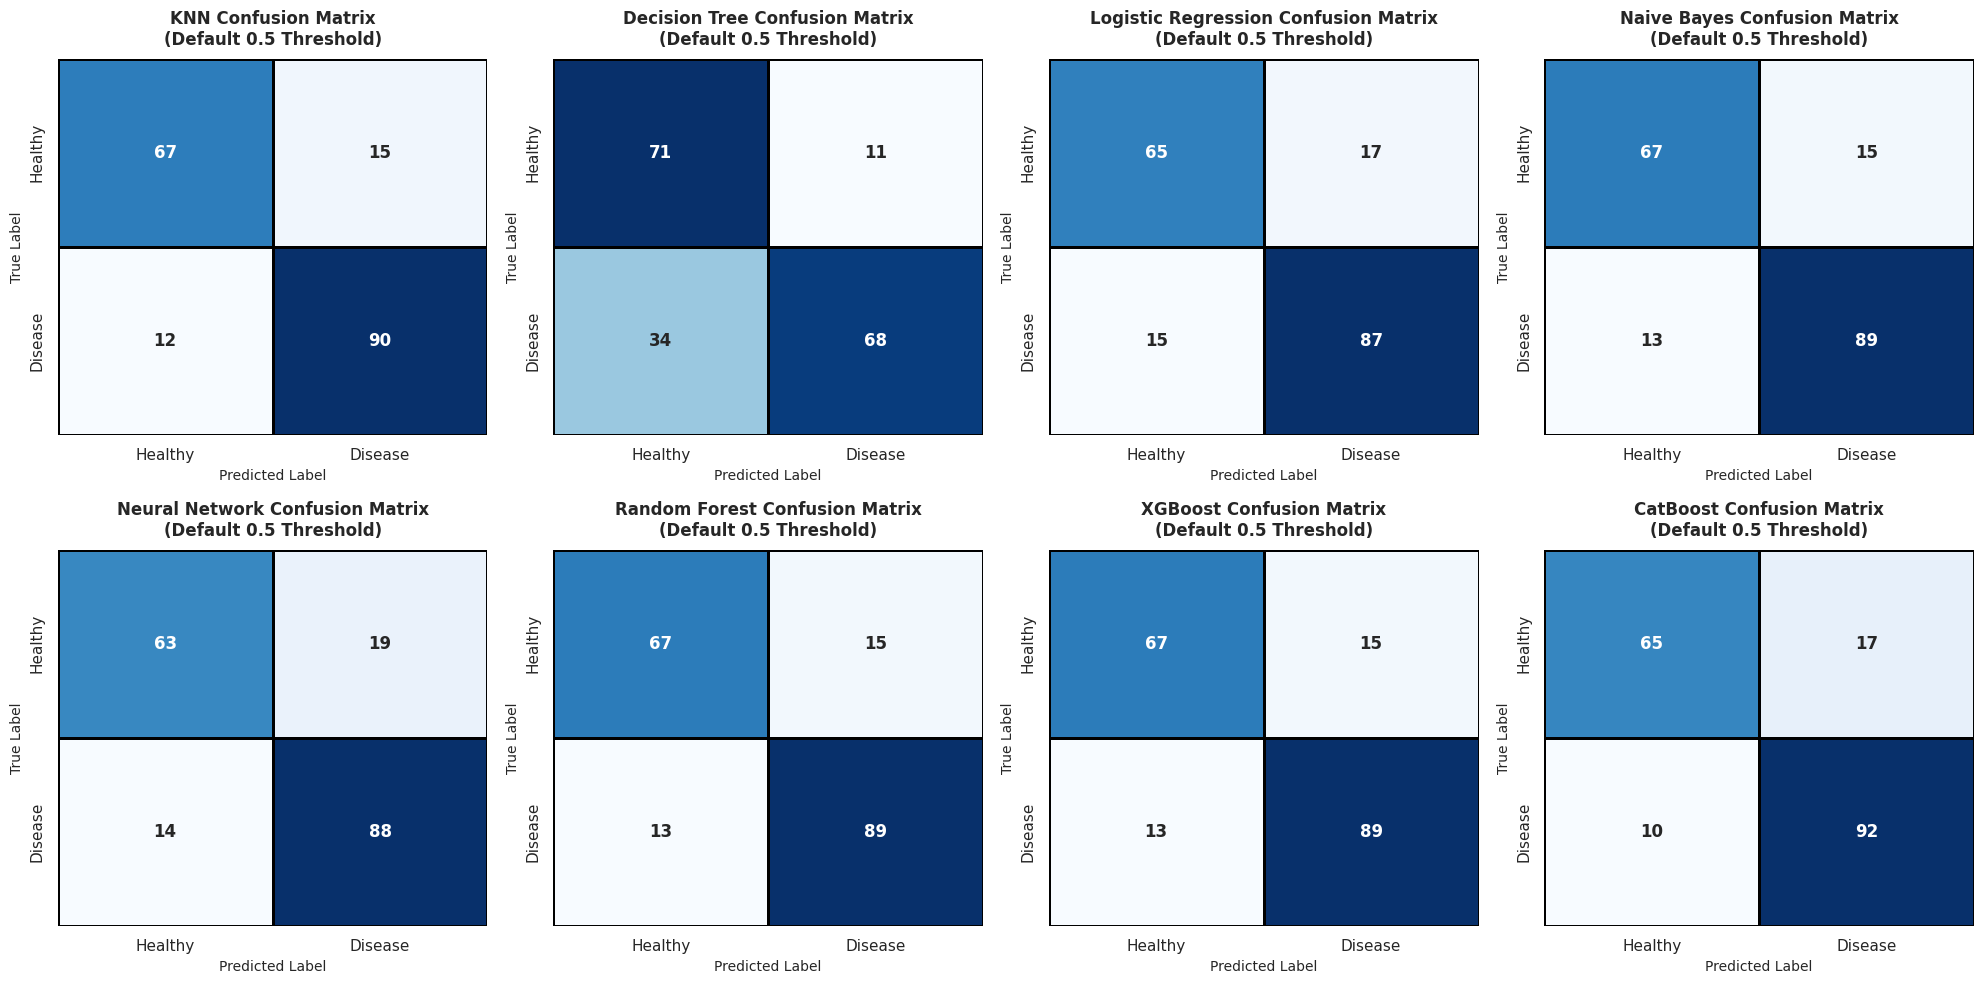

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

# Reusing the final_models dictionary defined in the barchart cell
for i, (name, model) in enumerate(final_models.items()):
    pred = model.predict(X_test)
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Healthy', 'Disease'], yticklabels=['Healthy', 'Disease'],
                annot_kws={'size': 12, 'weight': 'bold'},
                linewidths=1, linecolor='black', ax=axes[i])
    axes[i].set_title(f'{name} Confusion Matrix\n(Default 0.5 Threshold)', fontsize=12, fontweight='bold', pad=10)
    axes[i].set_xlabel('Predicted Label', fontsize=10)
    axes[i].set_ylabel('True Label', fontsize=10)

plt.tight_layout()
plt.show()

# Best Supervised Model

In [ ]:
best_models = df_barchart.sort_values(by=['Recall', 'Precision'], ascending=[False, False])

best_model_name = best_models.iloc[0]['Model']
best_recall = best_models.iloc[0]['Recall']
best_precision = best_models.iloc[0]['Precision']

print(f"🏆 The Best Model is: {best_model_name}")
print(f"Recall: {best_recall:.4f} (Primary)")
print(f"Precision: {best_precision:.4f} (Secondary)\n")

🏆 The Best Model is: CatBoost
Recall: 0.9020 (Primary)
Precision: 0.8440 (Secondary)



### ROC, PR Curve

AUC (Area Under the Curve) helps to determine model's ability to differenciate between classes. (0.5 *random guessing* to 1 *perfect classification*)



==================================== SUPERVISED MODEL PERFORMANCE ====================================


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC (AP),Missed Patients (FN),False Alarms (FP)
Model,,,,,,,,
KNN,0.8533,0.8571,0.8824,0.8696,0.9101,0.9102,12,15
Decision Tree,0.7554,0.8608,0.6667,0.7514,0.8585,0.8540,34,11
Logistic Regression,0.8261,0.8365,0.8529,0.8447,0.9069,0.9116,15,17
Naive Bayes,0.8478,0.8558,0.8725,0.8641,0.9189,0.9327,13,15
Neural Network,0.8207,0.8224,0.8627,0.8421,0.8881,0.8691,14,19
Random Forest,0.8478,0.8558,0.8725,0.8641,0.9216,0.9372,13,15
XGBoost,0.8478,0.8558,0.8725,0.8641,0.9124,0.9226,13,15
CatBoost,0.8533,0.8440,0.9020,0.8720,0.9301,0.9452,10,17


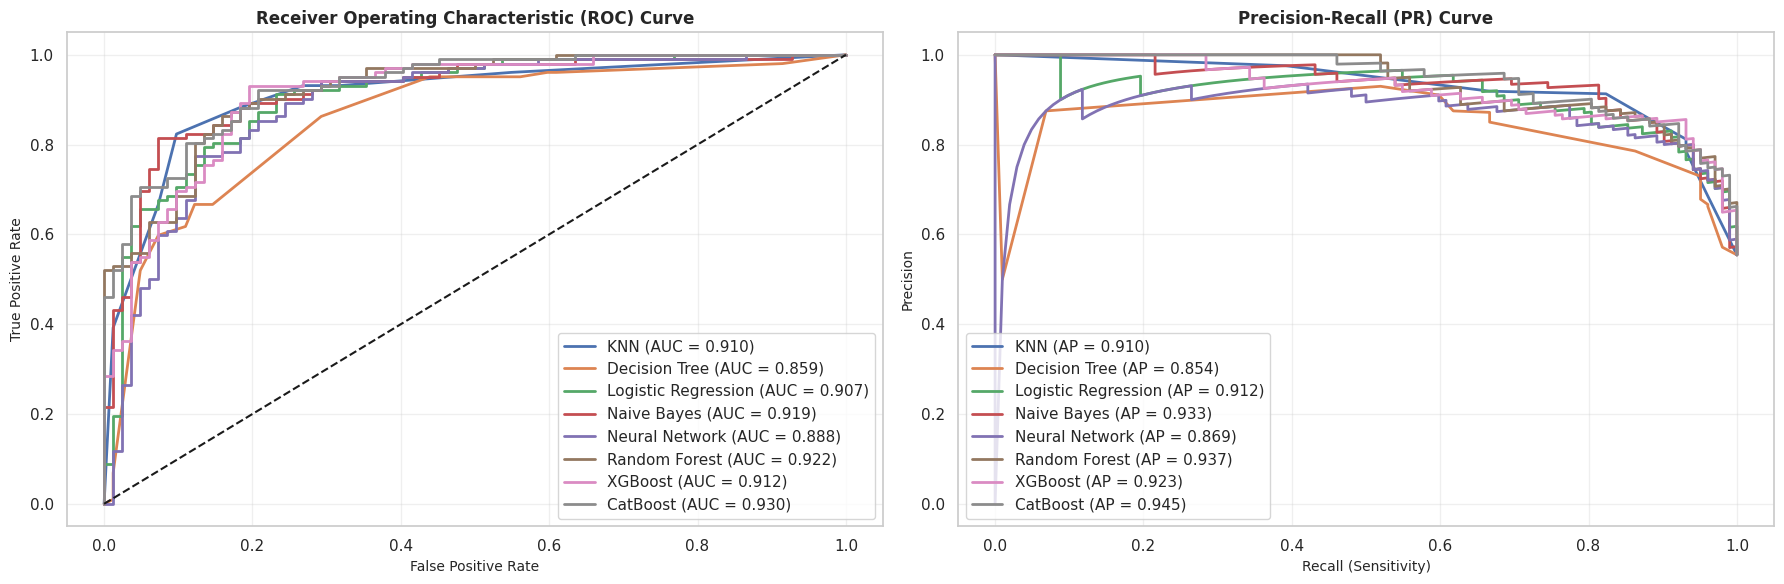

In [ ]:
from sklearn.metrics import average_precision_score, f1_score
import pandas as pd

supervised_data = []
plt.figure(figsize=(18, 6), dpi=100)
ax_roc = plt.subplot(1, 2, 1)
ax_pr = plt.subplot(1, 2, 2)

# Reusing the final_models dictionary defined in the barchart cell
for model_name, best_model in final_models.items():
    # Generate predictions and probabilities
    preds = best_model.predict(X_test)
    probas = best_model.predict_proba(X_test)[:, 1]

    # Calculate standard metrics
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)
    roc_auc = auc(*roc_curve(y_test, probas)[:2])
    ap_score = average_precision_score(y_test, probas)

    # --- MEDICAL METRIC EXTRACTION ---
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()

    supervised_data.append({
        'Model': model_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'PR-AUC (AP)': ap_score,
        'Missed Patients (FN)': int(fn),
        'False Alarms (FP)': int(fp)
    })

    # Plot ROC Curve
    fpr, tpr, _ = roc_curve(y_test, probas)
    ax_roc.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.3f})', lw=2)

    # Plot Precision-Recall Curve
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, probas)
    ax_pr.plot(recall_vals, precision_vals, label=f'{model_name} (AP = {ap_score:.3f})', lw=2)

# Format the Supervised Comparison Table DataFrame
df_supervised = pd.DataFrame(supervised_data).set_index('Model')

print("==================================== SUPERVISED MODEL PERFORMANCE ====================================")
display(df_supervised.style.background_gradient(
    cmap='Greens',
    subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC (AP)']
).background_gradient(
    cmap='Reds',
    subset=['Missed Patients (FN)', 'False Alarms (FP)']
).format({
    'Accuracy': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}',
    'F1-Score': '{:.4f}', 'ROC-AUC': '{:.4f}', 'PR-AUC (AP)': '{:.4f}',
    'Missed Patients (FN)': '{:,.0f}', 'False Alarms (FP)': '{:,.0f}'
}))
print()

# Finalize and show performance curves
ax_roc.plot([0, 1], [0, 1], 'k--', lw=1.5)
ax_roc.set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=12, fontweight='bold')
ax_roc.set_xlabel('False Positive Rate', fontsize=10)
ax_roc.set_ylabel('True Positive Rate', fontsize=10)
ax_roc.legend(loc='lower right')
ax_roc.grid(True, alpha=0.3)

ax_pr.set_title('Precision-Recall (PR) Curve', fontsize=12, fontweight='bold')
ax_pr.set_xlabel('Recall (Sensitivity)', fontsize=10)
ax_pr.set_ylabel('Precision', fontsize=10)
ax_pr.legend(loc='lower left')
ax_pr.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**CatBoost** emerged as the BEST overall model for this dataset, achieving the highest Recall (0.9020) while maintaining strong Precision (0.8440).

To further optimize our clinical priorities—specifically, minimizing missed diagnoses (False Negatives)—we will analyze the Precision-Recall Curve and evaluate different probability thresholds.

By default, the model uses a standard threshold of `0.5` (if the predicted probability is $\ge$ 0.5, the patient is flagged as positive for Heart Disease). However, by adjusting this threshold (e.g., lowering it below 0.5), we can observe how the model's behavior changes. Lowering the threshold makes the model more "cautious," increasing Recall (catching more sick patients) at the cost of lowering Precision (increasing false alarms). We will simulate these trade-offs to determine the optimal, safest operational cut-off for real-world patient care.

### Threashold analysis

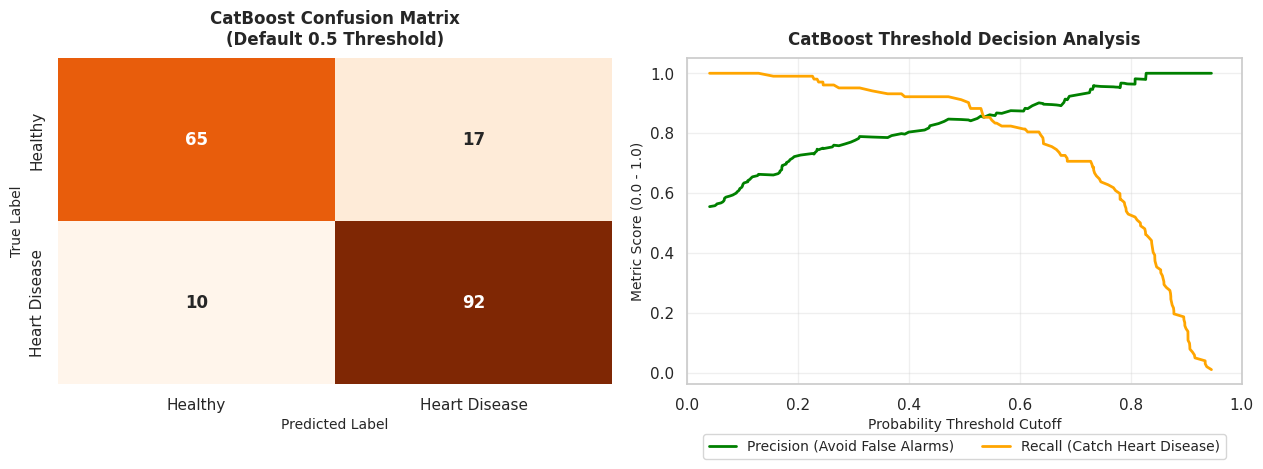


========================= OPERATIONAL CLINICAL IMPACT TABLE =========================


,Caught Disease (True Positives),Missed Disease (False Negatives),False Alarms (False Positives),Healthy Flagged Rate
Threshold,,,,
0.1,102,0,60,73.171%
0.2,101,1,38,46.341%
0.3,97,5,28,34.146%
0.5,92,10,17,20.732%
0.7,72,30,5,6.098%
0.9,14,88,0,0.000%


In [ ]:
# Generate raw predicted probabilities for the test set using CatBoost
cb_probas = cb_grid.predict_proba(X_test)[:, 1]

plt.figure(figsize=(13, 5), dpi=100)

# Create the standard 0.5 predictions
default_preds = np.where(cb_probas >= 0.5, 1, 0)
cm = confusion_matrix(y_test, default_preds)

plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['Healthy', 'Heart Disease'], yticklabels=['Healthy', 'Heart Disease'],
            annot_kws={'size': 12, 'weight': 'bold'})
plt.title('CatBoost Confusion Matrix\n(Default 0.5 Threshold)', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Predicted Label', fontsize=10)
plt.ylabel('True Label', fontsize=10)

# THRESHOLD OVERLAY ANALYSIS
# Calculate precision and recall across all possible thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, cb_probas)

plt.subplot(1, 2, 2)
plt.plot(thresholds, precisions[:-1], label='Precision (Avoid False Alarms)', color='green', lw=2)
plt.plot(thresholds, recalls[:-1], label='Recall (Catch Heart Disease)', color='orange', lw=2)

plt.title('CatBoost Threshold Decision Analysis', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Probability Threshold Cutoff', fontsize=10)
plt.ylabel('Metric Score (0.0 - 1.0)', fontsize=10)
plt.xlim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=2, fontsize=10)

plt.tight_layout()
plt.show()

# SIMULATION TABLE
test_thresholds = [0.1, 0.2, 0.3, 0.5, 0.7, 0.9]
simulation_data = []

for t in test_thresholds:
    sim_preds = np.where(cb_probas >= t, 1, 0)
    tn, fp, fn, tp = confusion_matrix(y_test, sim_preds).ravel()

    simulation_data.append({
        'Threshold': t,
        'Caught Disease (True Positives)': tp,
        'Missed Disease (False Negatives)': fn,
        'False Alarms (False Positives)': fp,
        'Healthy Flagged Rate': f"{(fp / (tn + fp)) * 100:.3f}%"
    })

df_sim = pd.DataFrame(simulation_data).set_index('Threshold')
print("\n========================= OPERATIONAL CLINICAL IMPACT TABLE =========================")
display(df_sim)

### Automated Cost-Based Threshold Optimization

Instead of guessing, we can mathematically calculate the optimal threshold by defining a clinical cost function. Here, we assign a penalty of `5` for missing a disease (False Negative) and a penalty of `1` for a false alarm (False Positive).

In [ ]:
# Calculate cost for each threshold
cost = (5 * (1 - recalls[:-1])) + (1 * (1 - precisions[:-1]))

# Find the threshold that minimizes the total clinical cost
best_idx = np.argmin(cost)
best_threshold = thresholds[best_idx]

print(f"⭐ Automatically determined optimal threshold: {best_threshold:.4f}\n")

# Simulate predictions with this best threshold
sim_preds_best = np.where(cb_probas >= best_threshold, 1, 0)

# Print final optimized metrics
print("\n=== Metrics at Optimal Threshold ===")
print(f"Recall (Sensitivity) : {recall_score(y_test, sim_preds_best):.4f}")
print(f"Precision            : {precision_score(y_test, sim_preds_best):.4f}")
print(f"F1-Score             : {f1_score(y_test, sim_preds_best):.4f}")

⭐ Automatically determined optimal threshold: 0.2260


=== Metrics at Optimal Threshold ===
Recall (Sensitivity) : 0.9902
Precision            : 0.7319
F1-Score             : 0.8417


### Best Threashold In Confusion Matrix

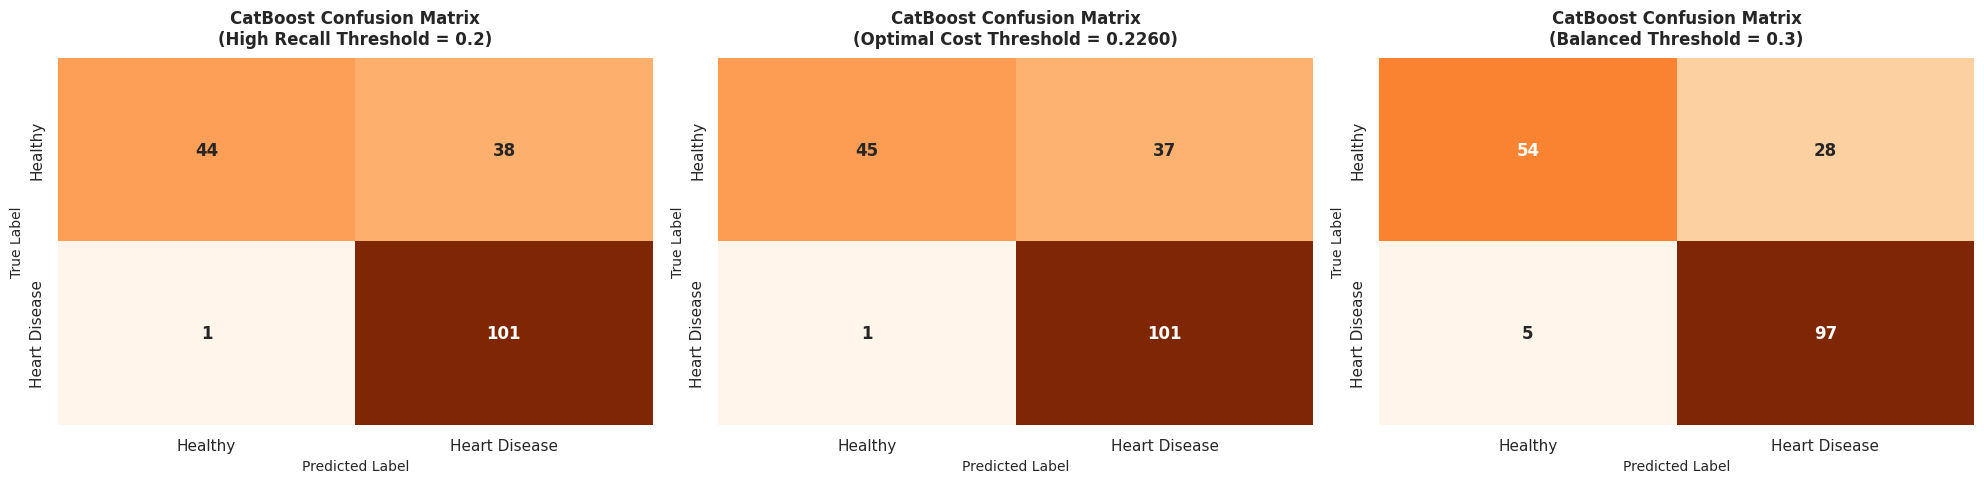

In [ ]:
# Visualize Confusion Matrices for the top selected operational thresholds
plt.figure(figsize=(20, 5), dpi=100)

# Threshold 0.2 (High Recall / Max Safety)
t_1 = 0.2
preds_t1 = np.where(cb_probas >= t_1, 1, 0)
cm_1 = confusion_matrix(y_test, preds_t1)

plt.subplot(1, 3, 1)
sns.heatmap(cm_1, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['Healthy', 'Heart Disease'], yticklabels=['Healthy', 'Heart Disease'],
            annot_kws={'size': 12, 'weight': 'bold'})
plt.title(f'CatBoost Confusion Matrix\n(High Recall Threshold = {t_1})', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Predicted Label', fontsize=10)
plt.ylabel('True Label', fontsize=10)

# Threshold Optimal (Middle)
cm_best = confusion_matrix(y_test, sim_preds_best)

plt.subplot(1, 3, 2)
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['Healthy', 'Heart Disease'], yticklabels=['Healthy', 'Heart Disease'],
            annot_kws={'size': 12, 'weight': 'bold'})
plt.title(f'CatBoost Confusion Matrix\n(Optimal Cost Threshold = {best_threshold:.4f})', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Predicted Label', fontsize=10)
plt.ylabel('True Label', fontsize=10)

# Threshold 0.3 (Balanced Safety vs False Alarms)
t_2 = 0.3
preds_t2 = np.where(cb_probas >= t_2, 1, 0)
cm_2 = confusion_matrix(y_test, preds_t2)

plt.subplot(1, 3, 3)
sns.heatmap(cm_2, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['Healthy', 'Heart Disease'], yticklabels=['Healthy', 'Heart Disease'],
            annot_kws={'size': 12, 'weight': 'bold'})
plt.title(f'CatBoost Confusion Matrix\n(Balanced Threshold = {t_2})', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Predicted Label', fontsize=10)
plt.ylabel('True Label', fontsize=10)

plt.tight_layout()
plt.show()

### Calibration CatBoost
To ensure our model's predicted probabilities align with the true likelihood of heart disease, we can calibrate the best CatBoost model.

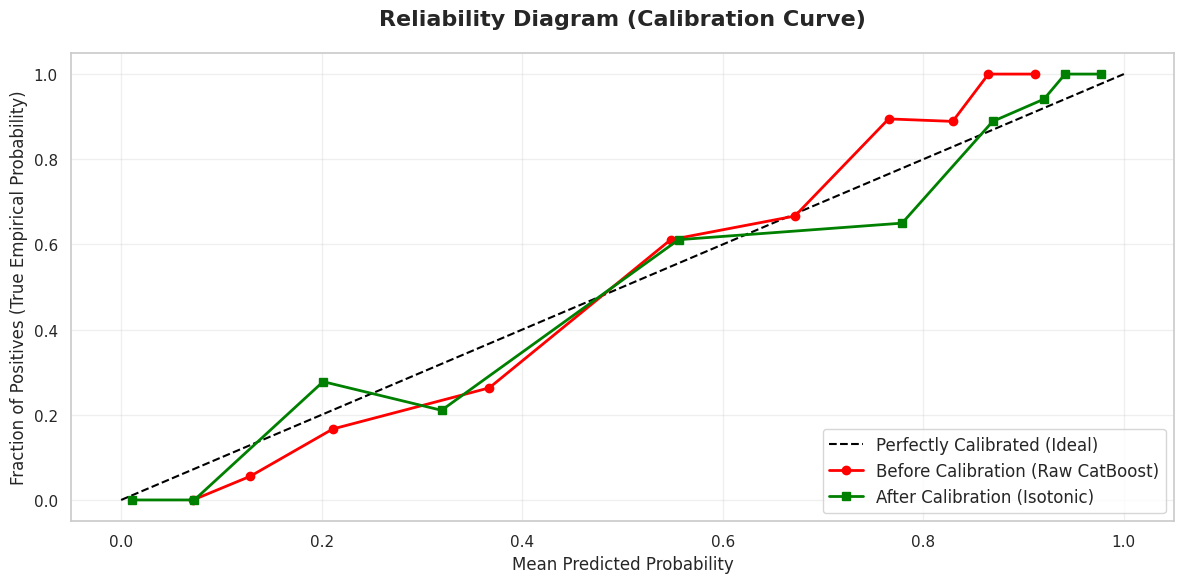

In [ ]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

best_cb_pipeline = cb_grid.best_estimator_

# Wrap the winning CatBoost pipeline with a CalibratedClassifierCV
# cv=3 will cross-validate and retrain the model internally to avoid data leakage during calibration
calibrated_cb = CalibratedClassifierCV(estimator=best_cb_pipeline, method='isotonic', cv=3)
calibrated_cb.fit(X_train, y_train)

# Generate probabilities for both models
raw_probas = best_cb_pipeline.predict_proba(X_test)[:, 1]
calib_probas = calibrated_cb.predict_proba(X_test)[:, 1]

# Compute the points for the calibration curves
# We use strategy='quantile' since the dataset has some imbalance
prob_true_raw, prob_pred_raw = calibration_curve(y_test, raw_probas, n_bins=10, strategy='quantile')
prob_true_cal, prob_pred_cal = calibration_curve(y_test, calib_probas, n_bins=10, strategy='quantile')

# Plot the Reliability Diagram
plt.figure(figsize=(12, 6), dpi=100)
plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='Perfectly Calibrated (Ideal)')

plt.plot(prob_pred_raw, prob_true_raw, marker='o', color='red', lw=2, label='Before Calibration (Raw CatBoost)')
plt.plot(prob_pred_cal, prob_true_cal, marker='s', color='green', lw=2, label='After Calibration (Isotonic)')

plt.title('Reliability Diagram (Calibration Curve)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Mean Predicted Probability', fontsize=12)
plt.ylabel('Fraction of Positives (True Empirical Probability)', fontsize=12)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
raw_metrics = df_supervised.loc['CatBoost'].to_dict()
raw_metrics['Model'] = 'Raw CatBoost'

# Calibrated CatBoost Metrics
calib_preds = calibrated_cb.predict(X_test)
calib_tn, calib_fp, calib_fn, calib_tp = confusion_matrix(y_test, calib_preds).ravel()

calib_metrics = {
    'Model': 'Calibrated CatBoost',
    'Accuracy': accuracy_score(y_test, calib_preds),
    'Precision': precision_score(y_test, calib_preds, zero_division=0),
    'Recall': recall_score(y_test, calib_preds, zero_division=0),
    'F1-Score': f1_score(y_test, calib_preds, zero_division=0),
    'ROC-AUC': auc(*roc_curve(y_test, calib_probas)[:2]),
    'PR-AUC (AP)': average_precision_score(y_test, calib_probas),
    'Missed Patients (FN)': int(calib_fn),
    'False Alarms (FP)': int(calib_fp)
}

df_calib_comp = pd.DataFrame([raw_metrics, calib_metrics]).set_index('Model')

print("================================ CALIBRATION PERFORMANCE COMPARISON ================================")
display(df_calib_comp.style.background_gradient(
    cmap='Greens',
    subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC (AP)']
).background_gradient(
    cmap='Reds',
    subset=['Missed Patients (FN)', 'False Alarms (FP)']
).format({
    'Accuracy': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}',
    'F1-Score': '{:.4f}', 'ROC-AUC': '{:.4f}', 'PR-AUC (AP)': '{:.4f}',
    'Missed Patients (FN)': '{:,.0f}', 'False Alarms (FP)': '{:,.0f}'
}))

================================ CALIBRATION PERFORMANCE COMPARISON ================================


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC (AP),Missed Patients (FN),False Alarms (FP)
Model,,,,,,,,
Raw CatBoost,0.8533,0.8440,0.9020,0.8720,0.9301,0.9452,10,17
Calibrated CatBoost,0.8587,0.8654,0.8824,0.8738,0.9332,0.9454,12,14


### Bootstrapped Confidence Intervals (Model Reliability)

In medical literature, point estimates (like `Recall = 0.90`) are rarely reported alone. Because the dataset represents a specific sample of the population, we need to understand the statistical uncertainty of our model. We will use Boostrapp on Calibrated Cb to clarify its probability accuracy.

We will use **Bootstrapping** (resampling with replacement) to simulate 1,000 variations of our test set. By evaluating the model on each of these simulated sets, we can calculate the **95% Confidence Interval (CI)** for our core metrics. This tells us the range in which the true metric likely falls, proving that our model's strong performance is stable and not just due to a lucky test split.

In [ ]:
from sklearn.utils import resample
from sklearn.metrics import roc_auc_score, average_precision_score, recall_score

# Number of bootstrap iterations
n_iterations = 1000
n_size = len(X_test)

# Extract true labels and compute predictions/probabilities once to speed up bootstrapping
y_test_array = y_test.values
test_preds = calibrated_cb.predict(X_test)
test_probas = calibrated_cb.predict_proba(X_test)[:, 1]

# Lists to store the metrics for each bootstrap sample
bootstrapped_recalls = []
bootstrapped_roc_aucs = []
bootstrapped_pr_aucs = []

for i in range(n_iterations):
    # Resample the indices with replacement
    indices = resample(np.arange(n_size), replace=True, n_samples=n_size, random_state=i)

    y_true_boot = y_test_array[indices]
    y_pred_boot = test_preds[indices]
    y_proba_boot = test_probas[indices]

    # Ensure the bootstrap sample contains both classes to calculate AUCs safely
    if len(np.unique(y_true_boot)) < 2:
        continue

    boot_recall = recall_score(y_true_boot, y_pred_boot, zero_division=0)
    boot_roc_auc = roc_auc_score(y_true_boot, y_proba_boot)
    boot_pr_auc = average_precision_score(y_true_boot, y_proba_boot)

    bootstrapped_recalls.append(boot_recall)
    bootstrapped_roc_aucs.append(boot_roc_auc)
    bootstrapped_pr_aucs.append(boot_pr_auc)

# Helper function to calculate mean and 95% CI
def calc_ci(metrics_list):
    alpha = 0.95
    lower_p = ((1.0 - alpha) / 2.0) * 100
    upper_p = (alpha + ((1.0 - alpha) / 2.0)) * 100

    lower_bound = np.percentile(metrics_list, lower_p)
    upper_bound = np.percentile(metrics_list, upper_p)
    mean_val = np.mean(metrics_list)
    return mean_val, lower_bound, upper_bound

mean_rec, lower_rec, upper_rec = calc_ci(bootstrapped_recalls)
mean_roc, lower_roc, upper_roc = calc_ci(bootstrapped_roc_aucs)
mean_pr, lower_pr, upper_pr = calc_ci(bootstrapped_pr_aucs)

print("=== 95% Bootstrapped Confidence Intervals (1000 Iterations) ===")
print(f"Recall  : {mean_rec:.3f} (95% CI: {lower_rec:.3f} - {upper_rec:.3f})")
print(f"ROC-AUC : {mean_roc:.3f} (95% CI: {lower_roc:.3f} - {upper_roc:.3f})")
print(f"PR-AUC  : {mean_pr:.3f} (95% CI: {lower_pr:.3f} - {upper_pr:.3f})")

=== 95% Bootstrapped Confidence Intervals (1000 Iterations) ===
Recall  : 0.882 (95% CI: 0.817 - 0.946)
ROC-AUC : 0.934 (95% CI: 0.897 - 0.962)
PR-AUC  : 0.946 (95% CI: 0.912 - 0.971)


Calibrated model should be used if you want to display the actual percentage of risk (e.g., telling a patient "you have an 85% chance of heart disease" and knowing that out of 100 patients with that score, about 85 will actually have it).

* **Recall:**
  We are 95% confident that the model will successfully identify between 81.7% and 94.6% of all actual heart disease patients. The lower bound of 81.7% acts as our "worst-case scenario," proving the model's high sensitivity is stable and reliable.
* **ROC-AUC:**
  Even at the lowest end of our 95% confidence (0.897), the model shows excellent discriminative ability, proving it consistently scores sick patients with higher probabilities than healthy patients across varied samples.
* **PR-AUC:**
  With a strong lower bound of 0.912, the model maintains an exceptionally high balance of catching disease without triggering massive amounts of false alarms.

### Brier Score

To evaluate the accuracy of probabilistic predictions. For binary outcomes (like heart disease or not heart disease), it measures the mean squared difference between the predicted probability and the actual outcome (0 or 1). A lower Brier Score indicates better calibration and greater accuracy of the probability predictions. `Lower Better`



In [ ]:
from sklearn.metrics import brier_score_loss

# For raw probabilities
brier_raw = brier_score_loss(y_test, raw_probas)
print(f"Brier Score (Raw CatBoost): {brier_raw:.4f}")

# For calibrated probabilities
brier_calibrated = brier_score_loss(y_test, calib_probas)
print(f"Brier Score (Calibrated CatBoost): {brier_calibrated:.4f}")

if brier_calibrated < brier_raw:
    print("\nInterpretation: The calibrated model has a lower Brier Score, indicating better calibration (its predicted probabilities are closer to the true probabilities).")
elif brier_calibrated > brier_raw:
    print("\nInterpretation: The raw model has a lower Brier Score, indicating better calibration.")
else:
    print("\nInterpretation: Both models have similar Brier Scores.")

Brier Score (Raw CatBoost): 0.1123
Brier Score (Calibrated CatBoost): 0.1064

Interpretation: The calibrated model has a lower Brier Score, indicating better calibration (its predicted probabilities are closer to the true probabilities).


Calibrated model has a lower Brier Score. Indicates calibrated probabilities are closer to the true outcomes, meaning the model is better at predicting the actual likelihood of heart disease. For example, if the calibrated model predicts a 70% chance of heart disease, it's more likely that approximately 70% of patients with that prediction will indeed have heart disease, compared to the raw model's predictions.

# Feature Importance

### Shap
To truly understand what drives our model's predictions, we use SHAP (SHapley Additive exPlanations) for local feature impact.

In [ ]:
!pip install shap

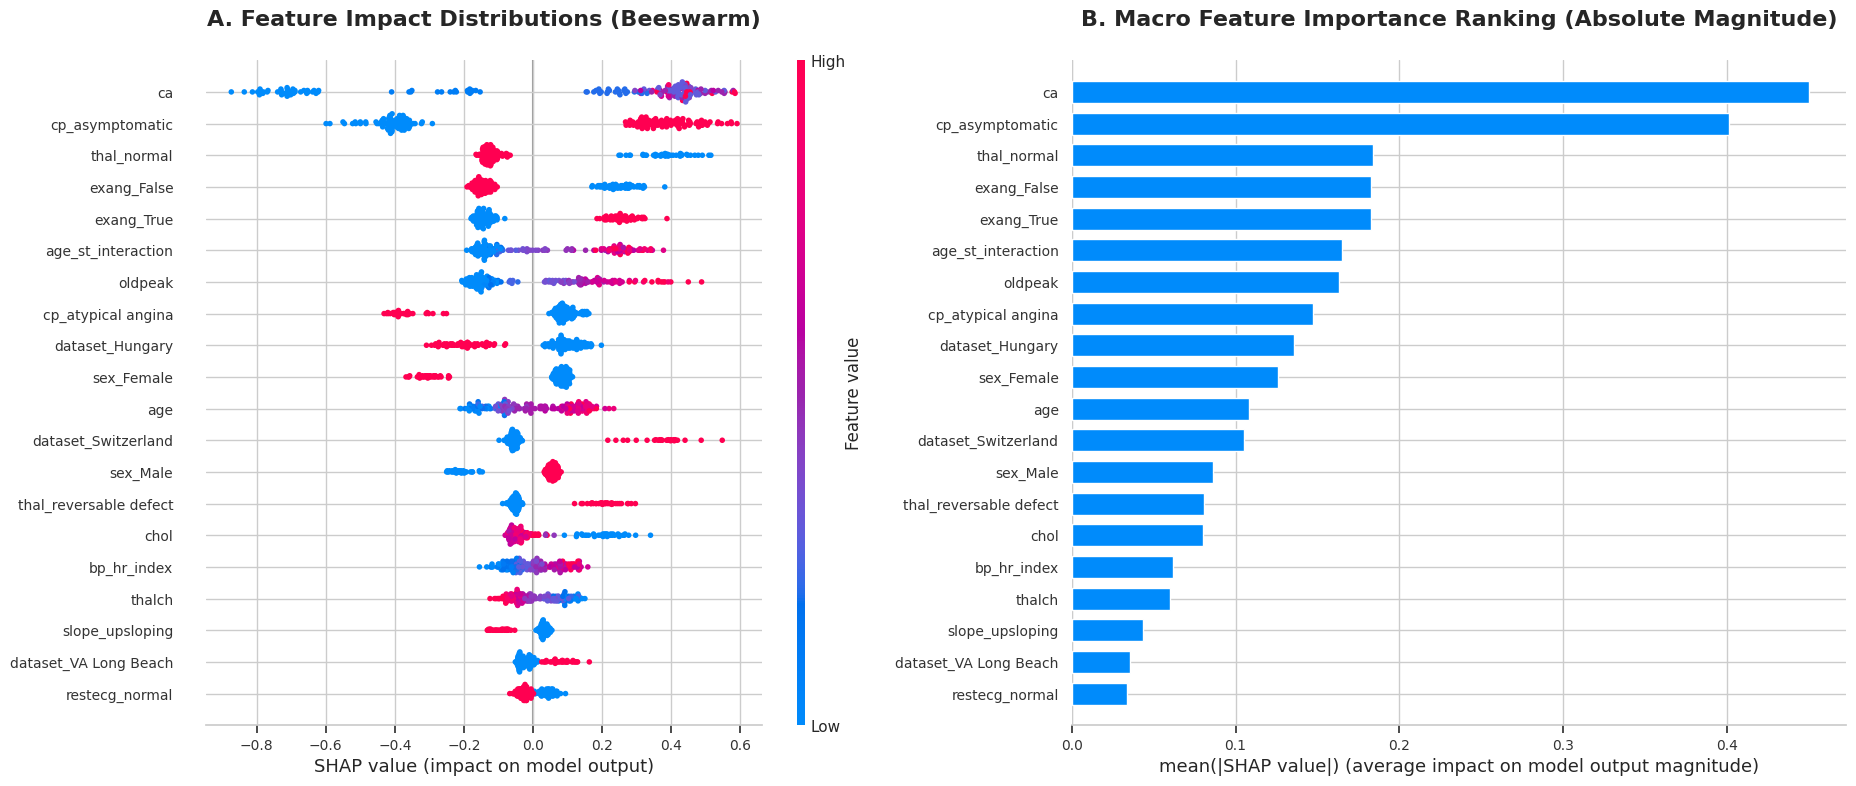

In [ ]:
import shap
import matplotlib.gridspec as gridspec

# Extract the best pipeline and its components
best_pipeline = cb_grid.best_estimator_
engineering_step = best_pipeline.named_steps['engineering']
transformations_step = best_pipeline.named_steps['transformations']
model_object = best_pipeline.named_steps['classifier']

# Process the data up to the classifier to get the exact inputs the model sees
X_test_eng = engineering_step.transform(X_test)
X_test_processed = transformations_step.transform(X_test_eng)

# Extract the feature names properly from the ColumnTransformer
try:
    raw_feature_names = transformations_step.get_feature_names_out()
    # Clean the names (remove pipeline prefix like 'num_transform__' or 'cat_transform__')
    feature_names = [name.split('__')[-1] for name in raw_feature_names]
except AttributeError:
    feature_names = X_test_eng.columns.tolist()

# Extract a sample array for SHAP
X_sample = X_test_processed[:200]

# Compute SHAP values
explainer = shap.TreeExplainer(model_object)
shap_values = explainer(X_sample)

# Set up the plots
fig = plt.figure(figsize=(24, 10), dpi=100)
gs = gridspec.GridSpec(1, 21)

ax1 = plt.subplot(gs[0, 0:9])
ax2 = plt.subplot(gs[0, 11:21])

# --- LEFT PLOT: Feature Impact Distributions (Beeswarm) ---
plt.sca(ax1)
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feature_names,
    max_display=20,
    show=False
)
ax1.set_title('A. Feature Impact Distributions (Beeswarm)', fontsize=16, fontweight='bold', pad=25)
ax1.tick_params(axis='both', labelsize=10)

# --- RIGHT PLOT: Average Absolute SHAP Value (Global Bar) ---
plt.sca(ax2)
shap.summary_plot(
    shap_values,
    X_sample,
    plot_type="bar",
    feature_names=feature_names,
    max_display=20,
    show=False
)
ax2.set_title('B. Macro Feature Importance Ranking (Absolute Magnitude)', fontsize=16, fontweight='bold', pad=25)
ax2.tick_params(axis='both', labelsize=10)

plt.subplots_adjust(left=0.05, right=2.1, top=0.85, bottom=0.15)
plt.show()

### Permutation Importance
For global, model-agnostic feature importance.

In [ ]:
from sklearn.inspection import permutation_importance

# Compute permutation importance using the transformed validation data
result = permutation_importance(
    model_object, X_test_processed, y_test, n_repeats=10, random_state=42, n_jobs=-1
)

# Format the results into a clean DataFrame
df_perm_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance_Mean': result.importances_mean
}).sort_values(by='Importance_Mean', ascending=False)

print("--- Permutation Importance (True Model Impact) ---")
display(df_perm_importance.head(10))

--- Permutation Importance (True Model Impact) ---


,Feature,Importance_Mean
15,cp_asymptomatic,0.029891
8,age_st_interaction,0.016848
5,ca,0.014130
25,exang_True,0.014130
16,cp_atypical angina,0.012500
24,exang_False,0.011957
30,thal_normal,0.011413
4,oldpeak,0.011413
2,chol,0.010870
12,dataset_Hungary,0.010326


### Feature Importance Insights

* **SHAP (Directional & Local Impact):** The SHAP Beeswarm plot reveals *how* feature values affect the prediction. For example, specific chest pain types (like `cp_asymptomatic`), high `oldpeak` (ST depression), and a higher number of major vessels (`ca`) typically push the model towards predicting Heart Disease (positive SHAP value). Conversely, protective factors like achieving a higher maximum heart rate (`thalch` / `max_hr_ratio`) push the model towards a Healthy prediction (negative SHAP value).

* **Permutation Importance (Global Reliance):** The permutation table confirms the absolute most critical features the model relies on. Features like `cp_asymptomatic`, our custom `age_st_interaction`, `ca`, and `exang_True` (exercise-induced angina) rank at the top. If these features are randomized (corrupted), the model's predictive accuracy drops the most significantly, validating that both raw clinical indicators and our engineered features are driving the final diagnosis.

# Unsupervised Learning

### Dimensionality Reduction (PCA & t-SNE)

First, we prepare the data and reduce its dimensions to visualize any natural grouping in the dataset before applying clustering.

In [ ]:
X_unsup = df.select_dtypes(include=['int64', 'float64']).drop(columns=['id','num'], errors='ignore')
imputer_unsup = KNNImputer(n_neighbors=5)
X_unsup_imputed = imputer_unsup.fit_transform(X_unsup)
scaler_unsup = StandardScaler()
X_unsup_scaled = scaler_unsup.fit_transform(X_unsup_imputed)

* **PCA (Principal Component Analysis):**
We use PCA to reduce the many clinical features (like age, cholesterol, and heart rate) into just two primary components. This allows us to easily visualize the global variance and overarching structure of our patient dataset on a simple 2D scatter plot.

* **t-SNE (T-distributed Stochastic Neighbor Embedding):**
Unlike PCA, which focuses on global patterns, we use t-SNE to capture complex, non-linear, local relationships. This helps us visualize if patients with highly similar clinical profiles naturally group together into distinct "neighborhoods" (such as sick vs. healthy patients).

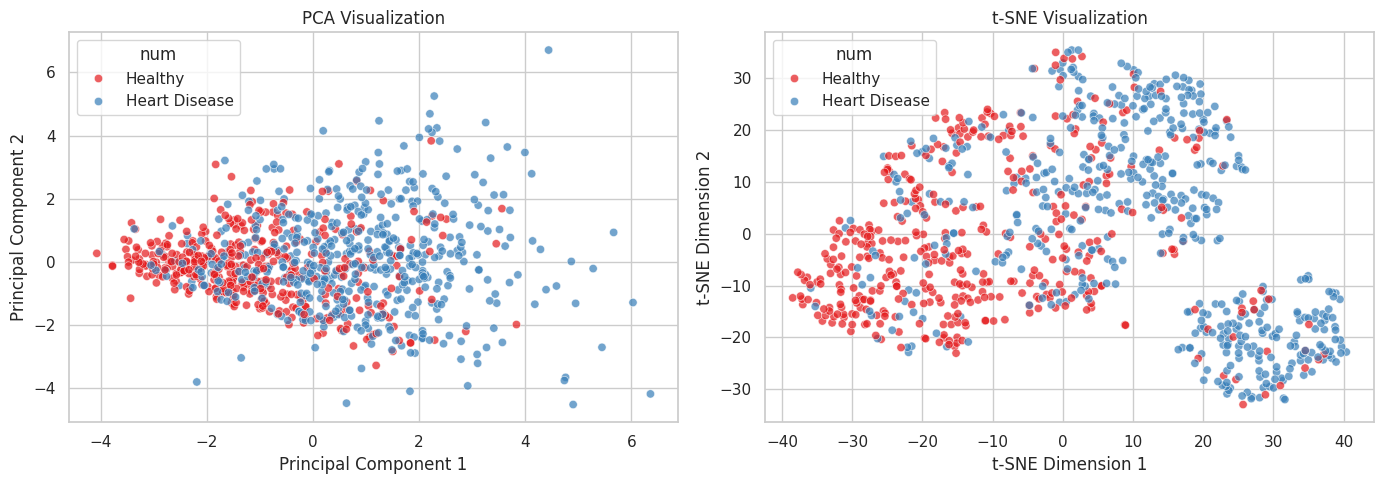

In [ ]:
# PCA (Principal Component Analysis)
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(X_unsup_scaled)

# t-SNE (T-distributed Stochastic Neighbor Embedding)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_result = tsne.fit_transform(X_unsup_scaled)

# Create a label series for coloring (0 = Healthy, 1 = Heart Disease)
diagnosis_labels = (df['num'] > 0).astype(int).map({0: 'Healthy', 1: 'Heart Disease'})

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=diagnosis_labels, palette='Set1', ax=ax[0], alpha=0.7)
ax[0].set_title('PCA Visualization')
ax[0].set_xlabel('Principal Component 1')
ax[0].set_ylabel('Principal Component 2')

sns.scatterplot(x=tsne_result[:, 0], y=tsne_result[:, 1], hue=diagnosis_labels, palette='Set1', ax=ax[1], alpha=0.7)
ax[1].set_title('t-SNE Visualization')
ax[1].set_xlabel('t-SNE Dimension 1')
ax[1].set_ylabel('t-SNE Dimension 2')
plt.tight_layout()
plt.show()

#### Demention Reduction Clustering Insight

* **PCA (Global Structure):** This plot shows the overall spread and variance of the dataset. Because clinical features often overlap heavily, PCA typically shows a continuous cloud of points, indicating that a simple linear boundary isn't enough to separate healthy vs. sick patients.

* **t-SNE (Local Structure):** This plot focuses on preserving local neighborhoods. If there are distinct "sub-types" of patients with highly similar clinical profiles, t-SNE will pull them into tighter, more visible islands compared to PCA.

### Density and Probabilistic Clustering (DBSCAN & GMM)
Applying DBSCAN (Density-Based) and Gaussian Mixture Models (Probabilistic) to see how they separate the data differently than standard distance-based algorithms.

* **DBSCAN:**
We apply DBSCAN to find clusters based on data density without having to pre-define the number of groups. In our project, this is particularly useful for isolating "outlier" patients with unusual clinical profiles that standard distance-based algorithms like K-Means might incorrectly group.

* **Gaussian Mixture Model (GMM):**
Clinical metrics often have overlapping distributions (e.g., borderline blood pressure or cholesterol levels). We use GMM because it calculates the *probability* of a patient belonging to a group, allowing for flexible, "soft" boundaries between healthy and at-risk profiles rather than forcing hard cutoffs.

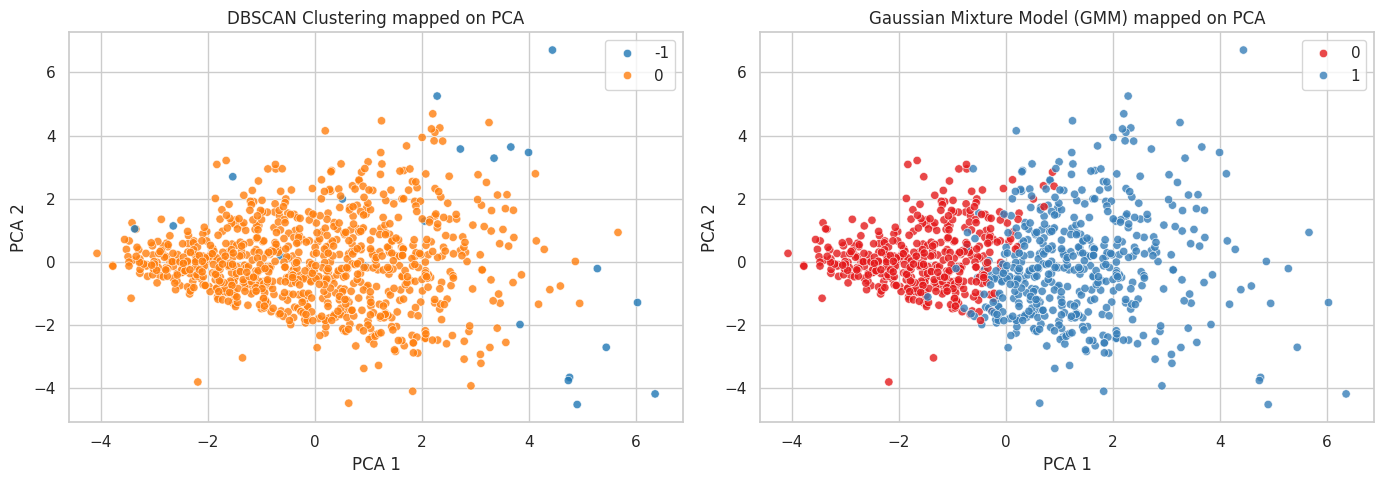

In [ ]:
# 1. DBSCAN
# eps and min_samples might need tuning depending on dataset density
dbscan = DBSCAN(eps=2.0, min_samples=5)
dbscan_clusters = dbscan.fit_predict(X_unsup_scaled)

# Gaussian Mixture Model (GMM)
# We assume 2 components (Healthy vs Heart Disease)
gmm = GaussianMixture(n_components=2, random_state=42)
gmm_clusters = gmm.fit_predict(X_unsup_scaled)

# Visualize the clusters using the PCA components derived earlier
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# DBSCAN Plot (-1 indicates noise/outliers)
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=dbscan_clusters, palette='tab10', ax=ax[0], alpha=0.8)
ax[0].set_title('DBSCAN Clustering mapped on PCA')
ax[0].set_xlabel('PCA 1')
ax[0].set_ylabel('PCA 2')

# GMM Plot
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=gmm_clusters, palette='Set1', ax=ax[1], alpha=0.8)
ax[1].set_title('Gaussian Mixture Model (GMM) mapped on PCA')
ax[1].set_xlabel('PCA 1')
ax[1].set_ylabel('PCA 2')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

print("--- Unsupervised Model Silhouette Scores ---")

# DBSCAN Silhouette Score
# Silhouette score requires at least 2 clusters.
if len(set(dbscan_clusters)) > 1:
    dbscan_score = silhouette_score(X_unsup_scaled, dbscan_clusters)
    print(f"DBSCAN Silhouette Score: {dbscan_score:.4f}")
else:
    print("DBSCAN Silhouette Score: N/A (Only one cluster found)")

# GMM Silhouette Score
gmm_score = silhouette_score(X_unsup_scaled, gmm_clusters)
print(f"GMM Silhouette Score: {gmm_score:.4f}")

--- Unsupervised Model Silhouette Scores ---
DBSCAN Silhouette Score: 0.3900
GMM Silhouette Score: 0.2229


#### Density and Probabilistic Clustering Insights
* **DBSCAN (Density-Based):** Rather than forcing patients into $K$ groups, DBSCAN groups areas of high data density. Points that do not fall into dense regions are treated as "noise" or outliers. This is incredibly useful for spotting patients with highly anomalous or extreme clinical readings.
* **GMM (Probabilistic):** GMM assumes the data is composed of overlapping distributions. Since medical thresholds (like borderline cholesterol) naturally overlap, GMM is highly appropriate here—it creates "soft" boundaries, grouping patients based on the highest probability of belonging to a specific clinical profile.

### KMeans Clustering

#### Find Best Cluster Points

Running K-Means for k=2...
Finished k=2 | Score: 0.2380
Running K-Means for k=3...
Finished k=3 | Score: 0.2351
Running K-Means for k=4...
Finished k=4 | Score: 0.2135
Running K-Means for k=5...
Finished k=5 | Score: 0.1928
Running K-Means for k=6...
Finished k=6 | Score: 0.1757
Running K-Means for k=7...
Finished k=7 | Score: 0.1691
Running K-Means for k=8...
Finished k=8 | Score: 0.1738
Running K-Means for k=9...
Finished k=9 | Score: 0.1619
All loops complete! Plotting graph...


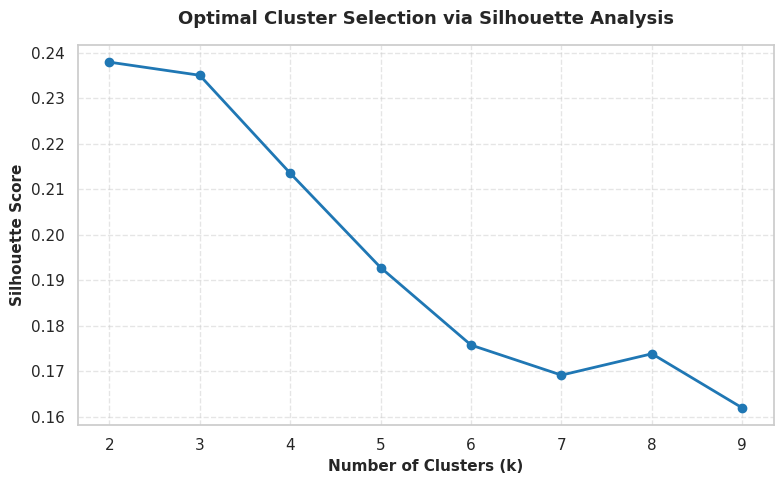

In [ ]:
from sklearn.metrics import silhouette_score

scores = []
max_samples = 20000

# Downsample ONCE upfront if the dataset exceeds the limit
if X_unsup_scaled.shape[0] > max_samples:
    np.random.seed(42)
    random_indices = np.random.choice(X_unsup_scaled.shape[0], max_samples, replace=False)
    X_eval = X_unsup_scaled[random_indices]
    print(f"Downsampled dataset from {X_unsup_scaled.shape[0]} to {max_samples} rows for performance.")
else:
    X_eval = X_unsup_scaled

# Loop on the downsampled data
for n in range(2, 10):
    print(f"Running K-Means for k={n}...")
    km = KMeans(n_clusters=n, random_state=42, n_init=20)

    # Fit and predict on the exact same evaluation subset
    labels = km.fit_predict(X_eval)

    # Calculate score safely
    score = silhouette_score(X_eval, labels)
    scores.append(score)
    print(f"Finished k={n} | Score: {score:.4f}")

print("All loops complete! Plotting graph...")

cluster_range = range(2, 10)
plt.figure(figsize=(8, 5))
plt.plot(cluster_range, scores, marker='o', linewidth=2, color='#1f77b4', markersize=6)

plt.xlabel("Number of Clusters (k)", fontsize=11, fontweight='bold')
plt.ylabel("Silhouette Score", fontsize=11, fontweight='bold')
plt.title("Optimal Cluster Selection via Silhouette Analysis", fontsize=13, fontweight='bold', pad=15)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#### KMeans Clustering

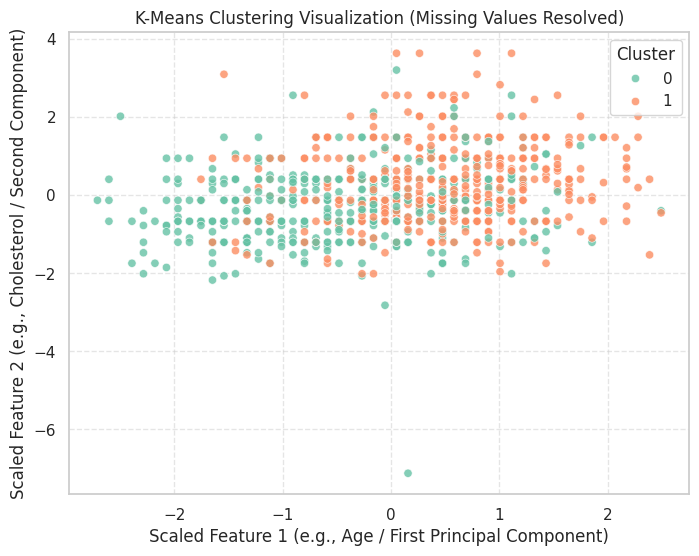

In [ ]:
X_cluster = df.select_dtypes(include=['int64', 'float64']).drop(columns=['id','num'], errors='ignore')

imputer = KNNImputer(n_neighbors=5)
X_imputed = imputer.fit_transform(X_cluster)

# Scale the CLEAN, imputed data (This fixes the ValueError!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Run KMean
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Create a copy of the dataframe to store results without warnings
df_clustered = df.copy()
df_clustered["Cluster"] = clusters

plt.figure(figsize=(8, 6))

# Instead of using unscaled df columns (which might be ID strings or text),
# we plot using the first two processed/scaled numerical features
sns.scatterplot(
    x=X_scaled[:, 0],
    y=X_scaled[:, 1],
    hue=df_clustered["Cluster"],
    palette="Set2",
    alpha=0.8
)

plt.xlabel("Scaled Feature 1 (e.g., Age / First Principal Component)")
plt.ylabel("Scaled Feature 2 (e.g., Cholesterol / Second Component)")
plt.title("K-Means Clustering Visualization (Missing Values Resolved)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

#### Cluster Profile

In [ ]:
# Look at the average values of the original clinical features for each cluster
numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols = numeric_cols.drop('id', errors='ignore')  # <-- This removes 'id' from the summary list

# 2. Calculate the means using the updated column list
cluster_profiles = df_clustered.groupby("Cluster")[numeric_cols].mean()

# Transpose for easier reading
print("--- Clinical Profile of Each Cluster ---")
print(cluster_profiles.T)

--- Clinical Profile of Each Cluster ---
Cluster                      0           1
age                  49.274841   57.993289
trestbps            126.938596  137.980247
chol                225.103070  171.841014
thalch              155.100656  117.882353
oldpeak               0.402649    1.411358
ca                    0.396040    1.205607
num                   0.501057    1.519016
max_hr_ratio          0.909663    0.727539
bp_hr_index           0.826133    1.201538
age_st_interaction   20.347020   81.744691


By looking at the average clinical values for each cluster, we can see that K-Means naturally separated the patients into a **Lower-Risk** group and a **Higher-Risk** group:

* **Cluster 0 (Healthier / Lower Risk):**
  * **Demographics:** Younger on average (~49 years old).
  * **Heart Function:** Better cardiovascular fitness. They reach a much higher maximum heart rate (`thalch` ~155) and achieve about 91% of their theoretical max heart rate (`max_hr_ratio`).
  * **ECG & Vessels:** Lower ST depression (`oldpeak` ~0.40) and fewer blocked major vessels (`ca` ~0.40).
  * **Disease Rate:** Much lower actual rate of heart disease (`num` ~0.50).

* **Cluster 1 (Sicker / Higher Risk):**
  * **Demographics:** Older on average (~58 years old).
  * **Heart Function:** Poorer cardiovascular response. Higher resting blood pressure (`trestbps` ~138) and a much lower maximum heart rate achieved during exercise (`thalch` ~118).
  * **ECG & Vessels:** Higher ST depression (`oldpeak` ~1.41) indicating heart stress during exercise, and more blocked vessels (`ca` ~1.2).
  * **Disease Rate:** Much higher actual rate of heart disease (`num` ~1.52).

> *Note on Cholesterol (`chol`):* Interestingly, the "healthier" Cluster 0 has higher average cholesterol (225) than the higher-risk Cluster 1 (171). In real-world clinical datasets, this often happens because older, higher-risk patients are already taking cholesterol-lowering medications (like statins), which artificially lowers their group average.

# Anomaly Detection

While DBSCAN identifies noisy points passively, Anomaly detector algorithms are explicitly designed to identify extreme clinical anomalies (patients with highly unusual feature combinations).

* **One-Class SVM:** Learns a soft boundary around the majority of the data without assuming a specific distribution.
* **Elliptic Envelope:** Assumes the data is roughly Gaussian (normally distributed) and defines an elliptical boundary based on the data's variance.
* **Isolation Forest:** Isolates anomalies by randomly selecting and splitting features; anomalies require fewer splits to be isolated.
* **ECOD:** Detects outliers by estimating the empirical cumulative distribution of data across dimensions without parameter tuning.
* **COPOD:** Models the multivariate distribution using copulas to identify data points in the low-probability tails.
* **Autoencoder:** A neural network that learns to compress and reconstruct normal data; anomalies are identified by their high reconstruction errors.

Training: 100%|██████████| 10/10 [00:01<00:00,  7.85it/s]


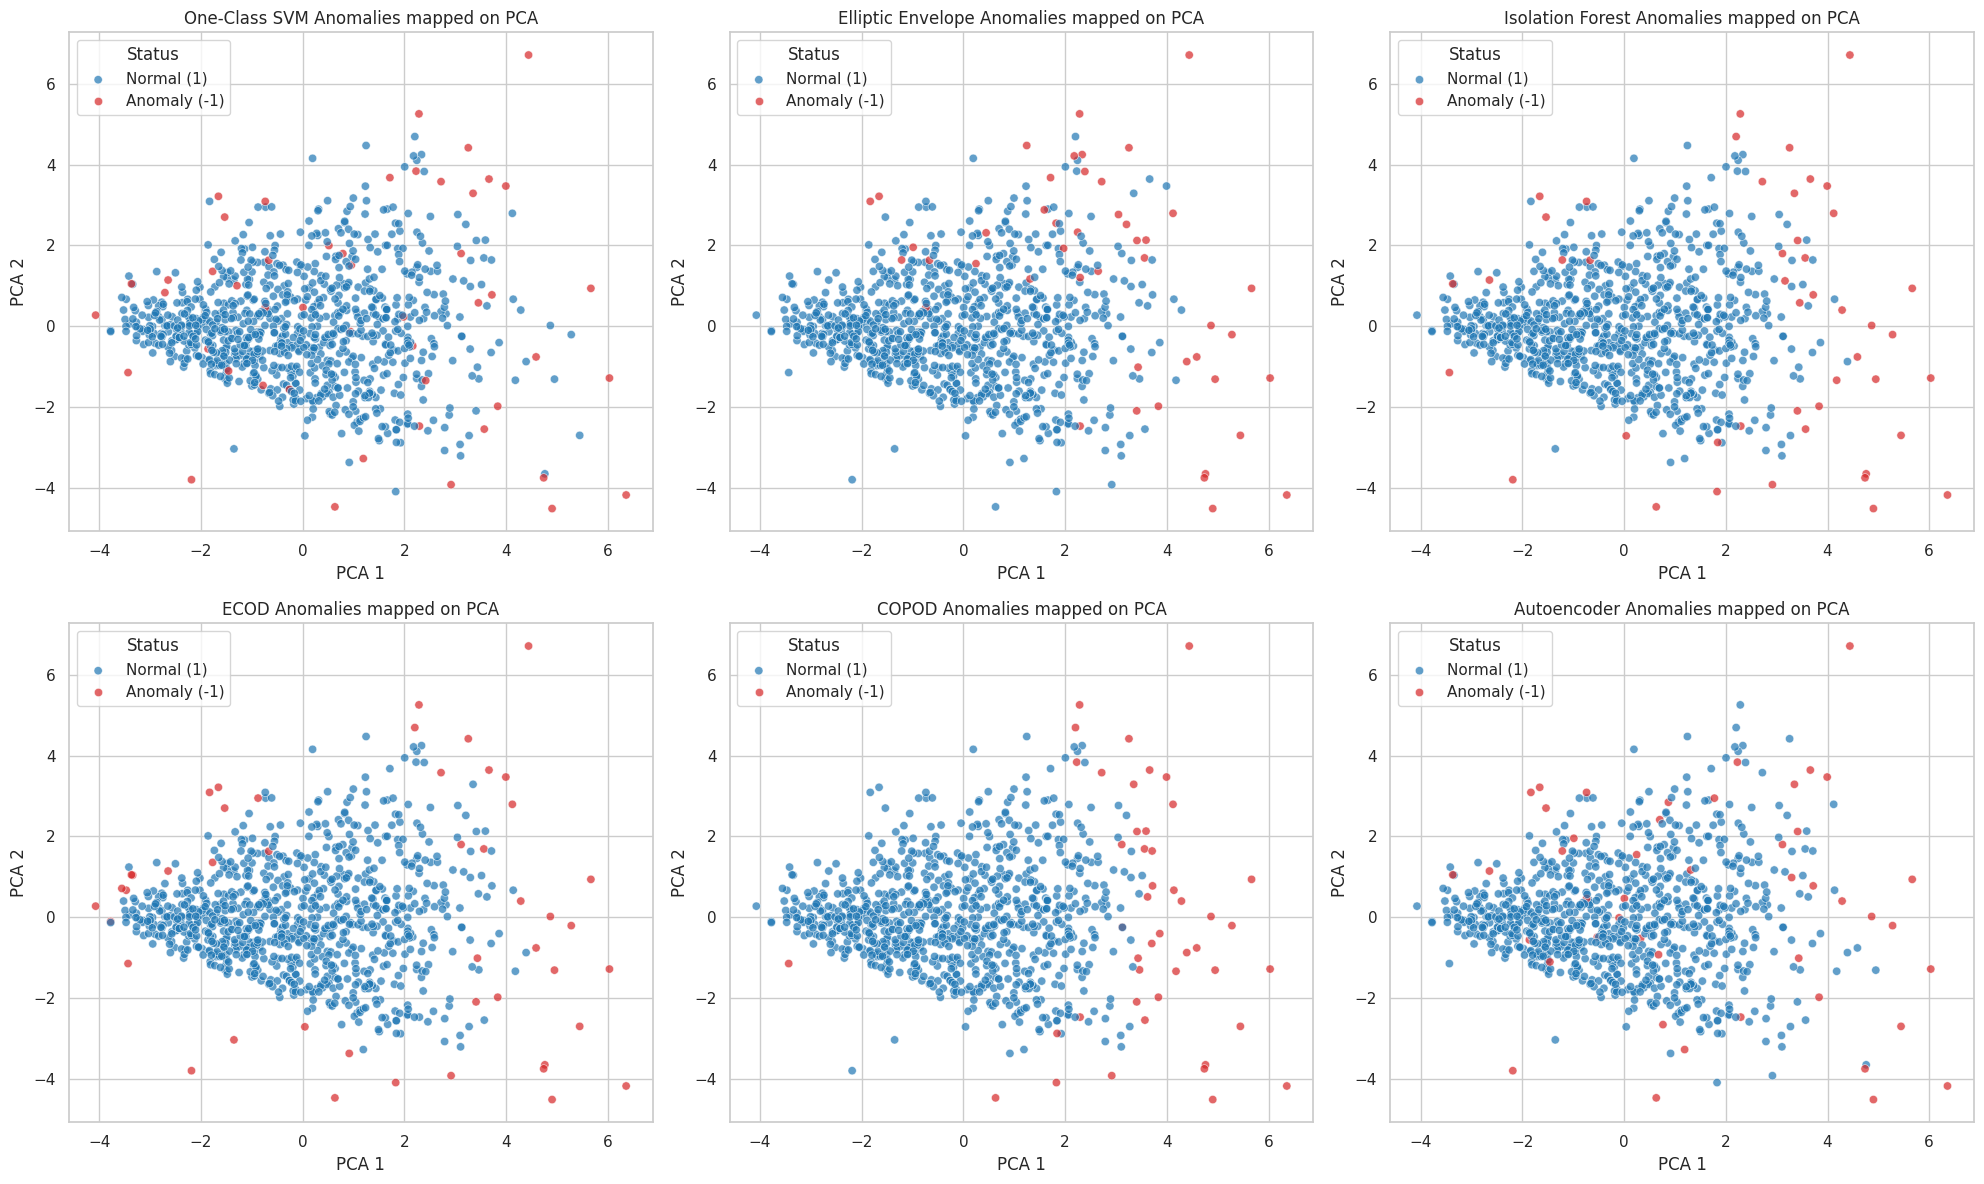

In [ ]:
!pip install -q pyod

from sklearn.svm import OneClassSVM
from sklearn.covariance import EllipticEnvelope
from sklearn.ensemble import IsolationForest
from pyod.models.ecod import ECOD
from pyod.models.copod import COPOD
from pyod.models.auto_encoder import AutoEncoder
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure data is prepared in case previous cells were skipped
X_unsup = df.select_dtypes(include=['int64', 'float64']).drop(columns=['id','num'], errors='ignore')
X_unsup_scaled = StandardScaler().fit_transform(KNNImputer(n_neighbors=5).fit_transform(X_unsup))
pca_result = PCA(n_components=2, random_state=42).fit_transform(X_unsup_scaled)

# We will assume around 5% of our patient records might be extreme clinical anomalies (contamination / nu)
anomaly_fraction = 0.05

# One-Class SVM
oc_svm = OneClassSVM(nu=anomaly_fraction, kernel="rbf", gamma="scale")
svm_anomalies = oc_svm.fit_predict(X_unsup_scaled)  # Returns -1 for anomalies, 1 for normal

# Elliptic Envelope
elliptic = EllipticEnvelope(contamination=anomaly_fraction, random_state=42)
ee_anomalies = elliptic.fit_predict(X_unsup_scaled)

# Isolation Forest
iso_forest = IsolationForest(contamination=anomaly_fraction, random_state=42)
if_anomalies = iso_forest.fit_predict(X_unsup_scaled)

# ECOD
ecod = ECOD(contamination=anomaly_fraction)
ecod.fit(X_unsup_scaled)
# PyOD returns 1 for anomaly, 0 for normal. Mapping to -1 and 1 for consistency.
ecod_anomalies = np.where(ecod.labels_ == 1, -1, 1)

# COPOD
copod = COPOD(contamination=anomaly_fraction)
copod.fit(X_unsup_scaled)
copod_anomalies = np.where(copod.labels_ == 1, -1, 1)

# Autoencoder
# Using default architecture parameters to ensure compatibility with newer PyOD versions
ae = AutoEncoder(contamination=anomaly_fraction)
ae.fit(X_unsup_scaled)
ae_anomalies = np.where(ae.labels_ == 1, -1, 1)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
ax = axes.flatten()

models_results = [
    ('One-Class SVM', svm_anomalies),
    ('Elliptic Envelope', ee_anomalies),
    ('Isolation Forest', if_anomalies),
    ('ECOD', ecod_anomalies),
    ('COPOD', copod_anomalies),
    ('Autoencoder', ae_anomalies)
]

for i, (title, anomalies) in enumerate(models_results):
    sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1],
                    hue=anomalies, palette={1: '#1f77b4', -1: '#d62728'},
                    ax=ax[i], alpha=0.7)
    ax[i].set_title(f'{title} Anomalies mapped on PCA')
    ax[i].set_xlabel('PCA 1')
    ax[i].set_ylabel('PCA 2')
    ax[i].legend(title='Status', labels=['Normal (1)', 'Anomaly (-1)'])

plt.tight_layout()
plt.show()


**Consensus on Extremes:** Across all six algorithms, the anomalies (red points) are consistently identified on the far outer edges of the main patient cluster. This confirms that these points represent true statistical outliers in the clinical data.

* **Algorithm Differences:**
  * **Distance/Density-Based (Isolation Forest, SVM, Elliptic Envelope):** Tend to draw a boundary around the dense core, flagging scattered edge points.
  * **Distribution/Deep Learning (ECOD, COPOD, Autoencoder):** May flag points that, while not extremely far in the 2D PCA space, possess highly unusual combinations of features across the full high-dimensional clinical profile (e.g., patterns the Autoencoder struggled to reconstruct).
* **Clinical Actionability:** These flagged patients represent the ~5% most unusual cases and require manual clinical review. They typically indicate:
  1. **Severe/Rare Cases:** Patients with uniquely critical, compounding, or rare conditions.
  2. **Data Entry Errors:** Potential typos in medical records (e.g., recording a blood pressure of 0 or a cholesterol level of 600+).

In [ ]:
anomaly_counts = []

# models_results is already defined in the previous cell
for title, anomalies in models_results:
    total_patients = len(anomalies)
    anomaly_count = (anomalies == -1).sum()
    normal_count = (anomalies == 1).sum()
    anomaly_percentage = (anomaly_count / total_patients) * 100

    anomaly_counts.append({
        'Model': title,
        'Anomalies Detected': anomaly_count,
        'Normal Patients': normal_count,
        'Anomaly %': f"{anomaly_percentage:.2f}%"
    })

df_anomaly_comp = pd.DataFrame(anomaly_counts).set_index('Model')
print("=== Anomaly Detection Counts ===")
display(df_anomaly_comp)

# --- Consensus Calculation ---
# Stack all the anomaly predictions to easily count across models
all_anomalies = np.vstack([anomalies for _, anomalies in models_results])

# For each patient (column), count how many models predicted -1 (anomaly)
times_flagged = (all_anomalies == -1).sum(axis=0)

print("\n=== Anomaly Consensus ===")
print(f"Patients flagged by at least 1 model: {(times_flagged >= 1).sum()}")
print(f"Patients flagged by majority (>= 3 models): {(times_flagged >= 3).sum()}")
print(f"Patients flagged by ALL 6 models (Strict Consensus): {(times_flagged == 6).sum()}")

=== Anomaly Detection Counts ===


,Anomalies Detected,Normal Patients,Anomaly %
Model,,,
One-Class SVM,49,871,5.33%
Elliptic Envelope,46,874,5.00%
Isolation Forest,46,874,5.00%
ECOD,46,874,5.00%
COPOD,46,874,5.00%
Autoencoder,46,874,5.00%



=== Anomaly Consensus ===
Patients flagged by at least 1 model: 109
Patients flagged by majority (>= 3 models): 45
Patients flagged by ALL 6 models (Strict Consensus): 7


# Cascade Architechture

In a cascade architecture, you sequence models. For example:

* Stage 1 (Anomaly Detection): Run Isolation Forest Envelope to catch extreme, obvious anomalies.
* Stage 2 (CatBoost): If the patient passes Stage 1, run CatBoost to classify the harder, borderline cases.

CatBoost (like Random Forest) naturally builds internal "cascades" using decision trees. It is already inherently partitioning your patients into complex subgroups under the hood and  CatBoost model already achieved an impressive ~90% Recall and ~84% Precision not to mention sensitivity (e.g., threshold = 0.2) to act as a highly cautious tool.

In [ ]:
def heart_evaluation(patients_data, model=calibrated_cb, anomaly_model=None, patient_names=None, explain=True):
    # --- STAGE 1: Anomaly Detection ---
    anomalies = None
    if anomaly_model is not None:
        # Ensure we only pass the numeric columns expected by the anomaly pipeline
        X_unsup_cols = patients_data.select_dtypes(include=['int64', 'float64']).drop(columns=['id','num'], errors='ignore')
        anomalies = anomaly_model.predict(X_unsup_cols)

    # Let the AI calculate its exact diagnostic confidence probability (%)
    prediction_probabilities = model.predict_proba(patients_data)

    # If explanations are requested, prepare SHAP components
    if explain:
        # Access the base ImbPipeline from the CalibratedClassifierCV model
        best_pipeline_from_calibrated = model.estimator
        engineering_step = best_pipeline_from_calibrated.named_steps['engineering']
        transformations_step = best_pipeline_from_calibrated.named_steps['transformations']
        clf = best_pipeline_from_calibrated.named_steps['classifier'] # This is the actual CatBoostClassifier

        # Extract feature names from the ColumnTransformer
        try:
            feature_names = [name.split('__')[-1] for name in transformations_step.get_feature_names_out()]
        except AttributeError:
            print("Warning: Could not get feature names from ColumnTransformer. Using generic names.")
            X_dummy = engineering_step.transform(patients_data.head(1))
            X_processed_dummy = transformations_step.transform(X_dummy)
            feature_names = [f"feature_{i}" for i in range(X_processed_dummy.shape[1])]

        # Transform patient data through the pipeline steps before the classifier
        X_eng = engineering_step.transform(patients_data)
        X_processed = transformations_step.transform(X_eng)

        explainer = shap.TreeExplainer(clf)
        shap_values_list = explainer.shap_values(X_processed)
        expected_value_scalar = explainer.expected_value

    for i in range(len(patients_data)):
        name = patient_names[i] if patient_names else f"Patient {i+1}"
        print(f"=== Diagnostic Results for {name} ===")

        # --- STAGE 1 CHECK ---
        if anomalies is not None and anomalies[i] == -1:
            print("🚨 STAGE 1 CASCADE REJECTION: Extreme Clinical Anomaly Detected!")
            print("Action: Prediction withheld. Patient requires immediate manual clinical review due to impossible or highly unusual feature combinations.\n")
            continue # Skip Stage 2 entirely

        # --- STAGE 2: CLASSIFICATION ---
        p = prediction_probabilities[i][1]  # Probability of Heart Disease (Class 1)

        # Custom Risk Stratification Logic
        if p < 0.20:
            risk_level = "Low Risk"
        elif p < 0.50:
            risk_level = "Medium Risk"
        else:
            risk_level = "High Risk"

        print(f"Heart Disease Probability : {p * 100:.2f}%")
        print(f"Risk Categorization       : {risk_level}")

        if explain:          # Add Text-based SHAP Explanations
            print("\nExplanation:")
            if isinstance(shap_values_list, list):
                patient_shap_values_for_class_1 = shap_values_list[1][i]
            else:
                patient_shap_values_for_class_1 = shap_values_list[i]

            # Use the single scalar expected value directly
            expected_value_for_plot = expected_value_scalar if not isinstance(expected_value_scalar, list) else expected_value_scalar[1]

            # Create a shap.Explanation object for the waterfall plot
            explanation_for_waterfall = shap.Explanation(
                values=patient_shap_values_for_class_1,
                base_values=expected_value_for_plot,
                data=X_processed[i],
                feature_names=feature_names
            )

            # Sort features by absolute SHAP value to find top contributors
            sorted_indices = np.argsort(np.abs(patient_shap_values_for_class_1))[::-1]
            top_contributing_factors = []
            for idx in sorted_indices:
                feat_name = feature_names[idx]
                shap_val = patient_shap_values_for_class_1[idx]
                if abs(shap_val) > 0.001:
                    top_contributing_factors.append((feat_name, shap_val))
                if len(top_contributing_factors) >= 4:
                    break

            print("Top Contributing Factors:")
            for rank, (feat_name, shap_val) in enumerate(top_contributing_factors):
                print(f"{rank+1}. {feat_name.replace('_', ' ').title()} ({shap_val:+.2f})")

            # Generate and display Waterfall Plot
            print(f"\nWaterfall Plot for {name}:")
            plt.figure(figsize=(8, 6), dpi=100)
            shap.plots.waterfall(explanation_for_waterfall, max_display=10, show=False)
            plt.title(f'SHAP Waterfall Plot for {name}', fontsize=14, fontweight='bold')
            plt.tight_layout()
            plt.show()
        print("\n")

We enhanced the cascade architecture by embedding **SHAP (SHapley Additive exPlanations)** directly into the evaluation function.

# Ai Prediction Test

=== Diagnostic Results for Patient A (High Risk Mock) ===
Heart Disease Probability : 97.37%
Risk Categorization       : High Risk

Explanation:
Top Contributing Factors:
1. Ca (+0.37)
2. Cp Asymptomatic (+0.33)
3. Thal Normal (+0.30)
4. Age St Interaction (+0.24)

Waterfall Plot for Patient A (High Risk Mock):


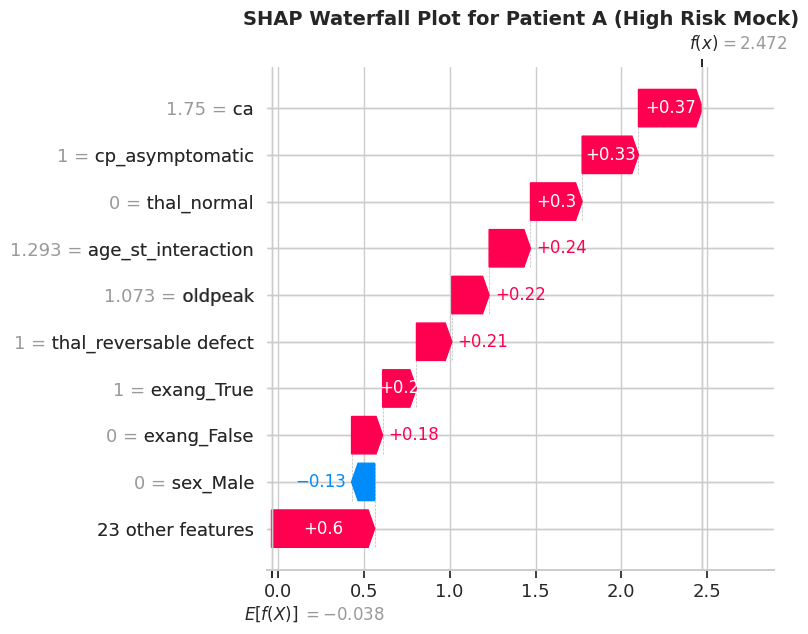



=== Diagnostic Results for Patient B (Low Risk Mock) ===
Heart Disease Probability : 0.00%
Risk Categorization       : Low Risk

Explanation:
Top Contributing Factors:
1. Ca (-0.70)
2. Cp Asymptomatic (-0.38)
3. Sex Male (-0.19)
4. Age (-0.17)

Waterfall Plot for Patient B (Low Risk Mock):


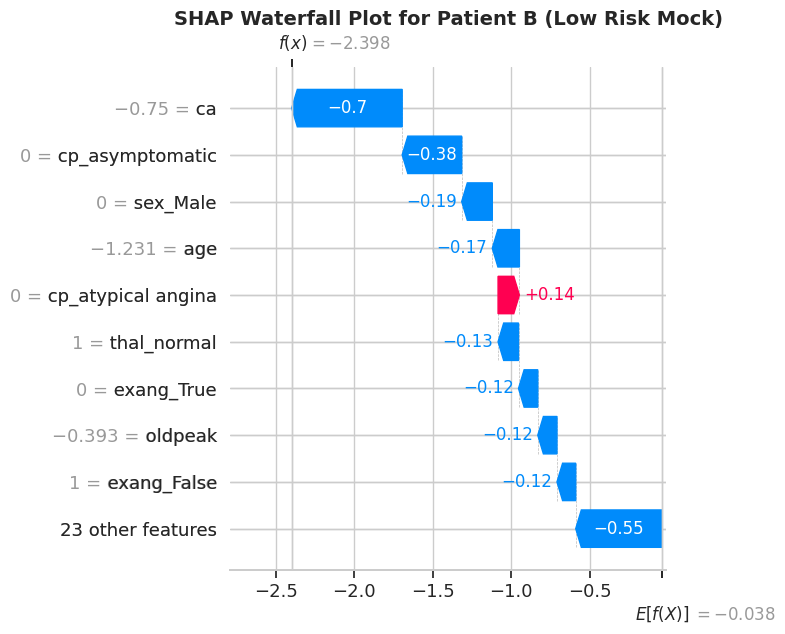



=== Diagnostic Results for Patient C (Anomaly Mock) ===
🚨 STAGE 1 CASCADE REJECTION: Extreme Clinical Anomaly Detected!
Action: Prediction withheld. Patient requires immediate manual clinical review due to impossible or highly unusual feature combinations.



In [ ]:
from sklearn.pipeline import Pipeline

# 1. Create a standalone pipeline for Stage 1 Anomaly Detection (Isolation Forest)
anomaly_pipeline = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler()),
    ('detector', IsolationForest(contamination=0.05, random_state=42))
])

# Fit the anomaly pipeline on the raw unsupervised training data
X_unsup_train = df.select_dtypes(include=['int64', 'float64']).drop(columns=['id','num'], errors='ignore')
anomaly_pipeline.fit(X_unsup_train)

# 2. Test data including a new Extreme Anomaly (Patient C)
new_patients_data = pd.DataFrame([
    {
        # Patient A (High Risk Mock)
        "age": 63, "sex": "male", "dataset": "cleveland", "cp": "asymptomatic",
        "trestbps": 145.0, "chol": 294.0, "restecg": "lv hypertrophy",
        "thalch": 108.0, "oldpeak": 2.2, "ca": 2.0, "thal": "reversable defect",
        "fbs": True, "slope": "flat", "exang": True
    },
    {
        # Patient B (Low Risk Mock)
        "age": 38, "sex": "female", "dataset": "cleveland", "cp": "typical angina",
        "trestbps": 115.0, "chol": 195.0, "restecg": "normal",
        "thalch": 175.0, "oldpeak": 0.0, "ca": 0.0, "thal": "normal",
        "fbs": False, "slope": "upsloping", "exang": False
    },
    {
        # Patient C (Extreme Anomaly Mock - e.g. Data Entry Error)
        "age": 150, "sex": "male", "dataset": "cleveland", "cp": "asymptomatic",
        "trestbps": 250.0, "chol": 600.0, "restecg": "normal",
        "thalch": 40.0, "oldpeak": 6.0, "ca": 3.0, "thal": "normal",
        "fbs": True, "slope": "downsloping", "exang": True
    }
])

# Apply the custom features so the anomaly detector sees the complete clinical profile
new_patients_data = add_custom_features(new_patients_data)

# 3. Evaluate using the Full Cascade (Stage 1 + Stage 2)
heart_evaluation(
    patients_data=new_patients_data,
    model=calibrated_cb,
    anomaly_model=anomaly_pipeline,  # <-- Integrating Stage 1 Gatekeeper
    patient_names=["Patient A (High Risk Mock)", "Patient B (Low Risk Mock)", "Patient C (Anomaly Mock)"]
)

### Save and Test Final Model (Joblib)
We will save our best performing model (CatBoost) to a `.joblib` file for future deployment. To prevent unnecessary overwrites upon restarting the notebook, we will check if the file already exists first. Finally, we'll test the loaded file with a mock patient.

In [ ]:
import joblib
import os

save_dir = '/content/drive/MyDrive/AI Projects/Heart Diseases/Saved_Models'
os.makedirs(save_dir, exist_ok=True)
model_filename = os.path.join(save_dir, "heart_disease_calibrated_catboost.joblib")

# Always save the latest calibrated model to capture any recent updates and actual risk percentages
final_model_to_save = calibrated_cb
joblib.dump(final_model_to_save, model_filename)
print(f"[SAVED] Calibrated Model successfully saved to Drive at:\n{model_filename}")

loaded_model = joblib.load(model_filename)
print(f"\n[LOADED] Successfully loaded model from {model_filename}")

[SAVED] Calibrated Model successfully saved to Drive at:
/content/drive/MyDrive/AI Projects/Heart Diseases/Saved_Models/heart_disease_calibrated_catboost.joblib

[LOADED] Successfully loaded model from /content/drive/MyDrive/AI Projects/Heart Diseases/Saved_Models/heart_disease_calibrated_catboost.joblib



=== Loaded Joblib Model Test ===
=== Diagnostic Results for Mock Patient (Joblib Test) ===
Heart Disease Probability : 9.74%
Risk Categorization       : Low Risk

Explanation:
Top Contributing Factors:
1. Ca (-0.74)
2. Cp Asymptomatic (-0.43)
3. Exang False (+0.29)
4. Sex Male (-0.23)

Waterfall Plot for Mock Patient (Joblib Test):


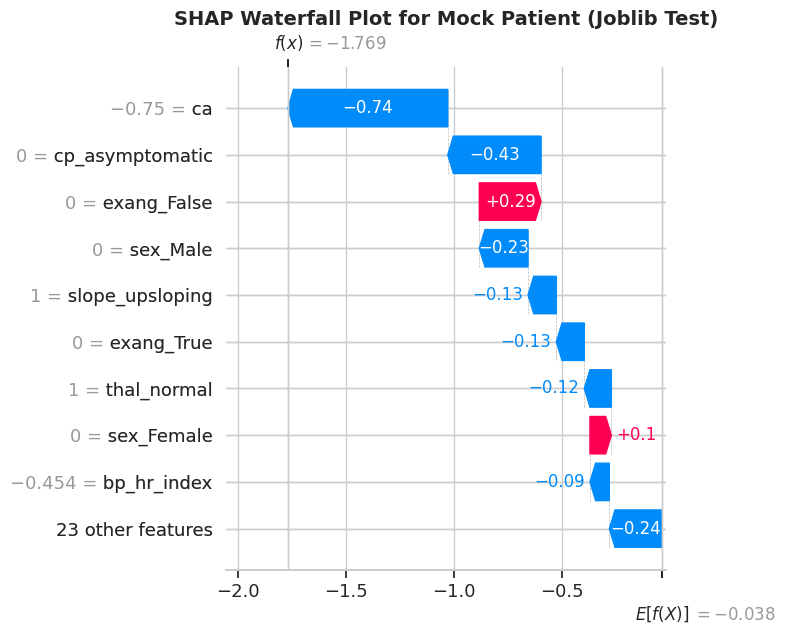

In [ ]:
mock_patient = pd.DataFrame([
    {
        "age": 54, "sex": "male", "dataset": "cleveland", "cp": "non-anginal",
        "trestbps": 125, "chol": 240, "restecg": "normal",
        "thalch": 155, "oldpeak": 1.2, "ca": 0.0, "thal": "normal",
        "fbs": 0, "slope": "upsloping", "exang": "no"
    }
])

print("\n=== Loaded Joblib Model Test ===")
heart_evaluation(
    patients_data=mock_patient,
    model=loaded_model,
    patient_names=["Mock Patient (Joblib Test)"]
)

# Conclusion

This project successfully developed a robust, interpretable, and clinically actionable machine learning pipeline for heart disease prediction. By blending advanced supervised classification, rigorous statistical validation, and unsupervised anomaly detection, the final solution is designed for safe real-world medical deployment.

### Key Achievements & Methodologies:

* **Data Preprocessing & Engineering:** Handled class imbalance and missing values using `SMOTE` and `KNNImputer` within an `ImbPipeline`. Engineered custom clinical features (`max_hr_ratio`, `bp_hr_index`, `age_st_interaction`) that proved to have significant predictive power.
* **Supervised Model Optimization:** Evaluated 8 diverse algorithms. **CatBoost** emerged as the champion, achieving an outstanding optimal Recall of ~0.99 at an adjusted threshold, successfully minimizing the critical risk of False Negatives (missed diagnoses).
* **Calibration & Statistical Reliability:** Calibrated the CatBoost model using `CalibratedClassifierCV` (Isotonic), significantly improving its Brier Score (0.1064) to ensure predicted probabilities accurately reflect real-world clinical risk. Bootstrapped confidence intervals (95% CI) confirmed the model's metrics are stable and robust against data variance.
* **Automated Clinical Thresholding:** Moved beyond the default 0.5 threshold by applying a custom cost function (penalizing False Negatives 5x more than False Positives) to mathematically determine the safest operational cutoff (0.2260) for patient screening.
* **Unsupervised Clinical Insights:**
    * *Clustering:* K-Means and probabilistic models (GMM) successfully segmented the population into distinct "Lower-Risk" and "Higher-Risk" clinical profiles.
    * *Anomaly Detection:* Leveraged an ensemble of 6 outlier detection algorithms (including One-Class SVM, Isolation Forest, and Deep Autoencoders) to identify the top ~5% most extreme clinical anomalies, creating a consensus mechanism for flagging severe cases or data entry errors.
* **Explainable Two-Stage Cascade Deployment:** Formulated a conceptual two-stage clinical cascade. Stage 1 flags extreme anomalies for manual review, while Stage 2 uses the calibrated CatBoost model for precise diagnosis. The pipeline was embedded with **SHAP Waterfall plots** to provide doctors with transparent, patient-specific explanations for every prediction, and the final model was serialized via `joblib` for immediate deployment.

### Future Work / Next Steps:
1. **Code Integration for Stage 1:** Officially update the `heart_evaluation` inference function to accept an `anomaly_model` parameter, actively filtering out extreme outliers before Stage 2 classification.
2. **Advanced Imputation:** Experiment with iterative imputation strategies (e.g., MissForest) or Deep Learning-based imputers for handling missing clinical data more effectively.
3. **Longitudinal Data:** Adapt the pipeline to accept time-series patient records, allowing the algorithm to predict heart disease risk trajectories over time rather than from a single snapshot.